<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/clustering_algrithms_on_kenyan_medical_facilities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

file_path = '/content/All_Facilities_Facilities_licensed_by_KMPDC_for_year_2024_as_at_7th_June_2024_at_5.csv'
df = pd.read_csv(file_path)

display(df.head())

,Reg_No,Facility_Name,Address,Facility_Type,Facility_Ownership,Level,Bed_Capacity,County,Status
0,019619,DANDELION ULLA MARIER CLINIC,P.O BOX 13226-20100 NAKURU,MEDICAL CLINIC,Private,LEVEL 2,0,BARINGO,LICENCED
1,GK-004476,BARINGO COUNTY REFERRAL HOSPITAL,P.O BOX 21-30400 KABARNET,HOSPITAL LEVEL 4,Public,LEVEL 4,100,BARINGO,LICENCED
2,GK-013469,ELDAMA RA VINE SUB-COUNTY HOSPITAL,P.O BOX 102-20103 ELDAMA RA VINE,HOSPITAL LEVEL 4,Public,LEVEL 4,120,BARINGO,LICENCED
3,000670,AIC ELDAMA RA VINE HEALTH CENTRE,P.O BOX 9-20103 ELDAMA RA VINE,HEALTH CENTRE,FAITH BASED ORGANIZATION (FBO),LEVEL 3B,10,BARINGO,LICENCED
4,000798,MERCY MISSION HOSPITAL,P.O BOX 10-20103 ELDAMA RA VINE,FAITH BASED LEVEL 4 HOSPITAL,FAITH BASED ORGANIZATION (FBO),LEVEL 4,110,BARINGO,LICENCED


In [2]:
# Display the shape of the dataset
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (7876, 9)


In [3]:
# Display the summary statistics of the dataset
display(df.describe())

,Bed_Capacity
count,7876.000000
mean,13.778822
std,45.224882
min,0.000000
25%,0.000000
50%,0.000000
75%,15.000000
max,1800.000000


In [4]:
# Display the concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7876 entries, 0 to 7875
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reg_No              7876 non-null   object
 1   Facility_Name       7876 non-null   object
 2   Address             7862 non-null   object
 3   Facility_Type       7876 non-null   object
 4   Facility_Ownership  7876 non-null   object
 5   Level               7876 non-null   object
 6   Bed_Capacity        7876 non-null   int64 
 7   County              7876 non-null   object
 8   Status              7876 non-null   object
dtypes: int64(1), object(8)
memory usage: 553.9+ KB


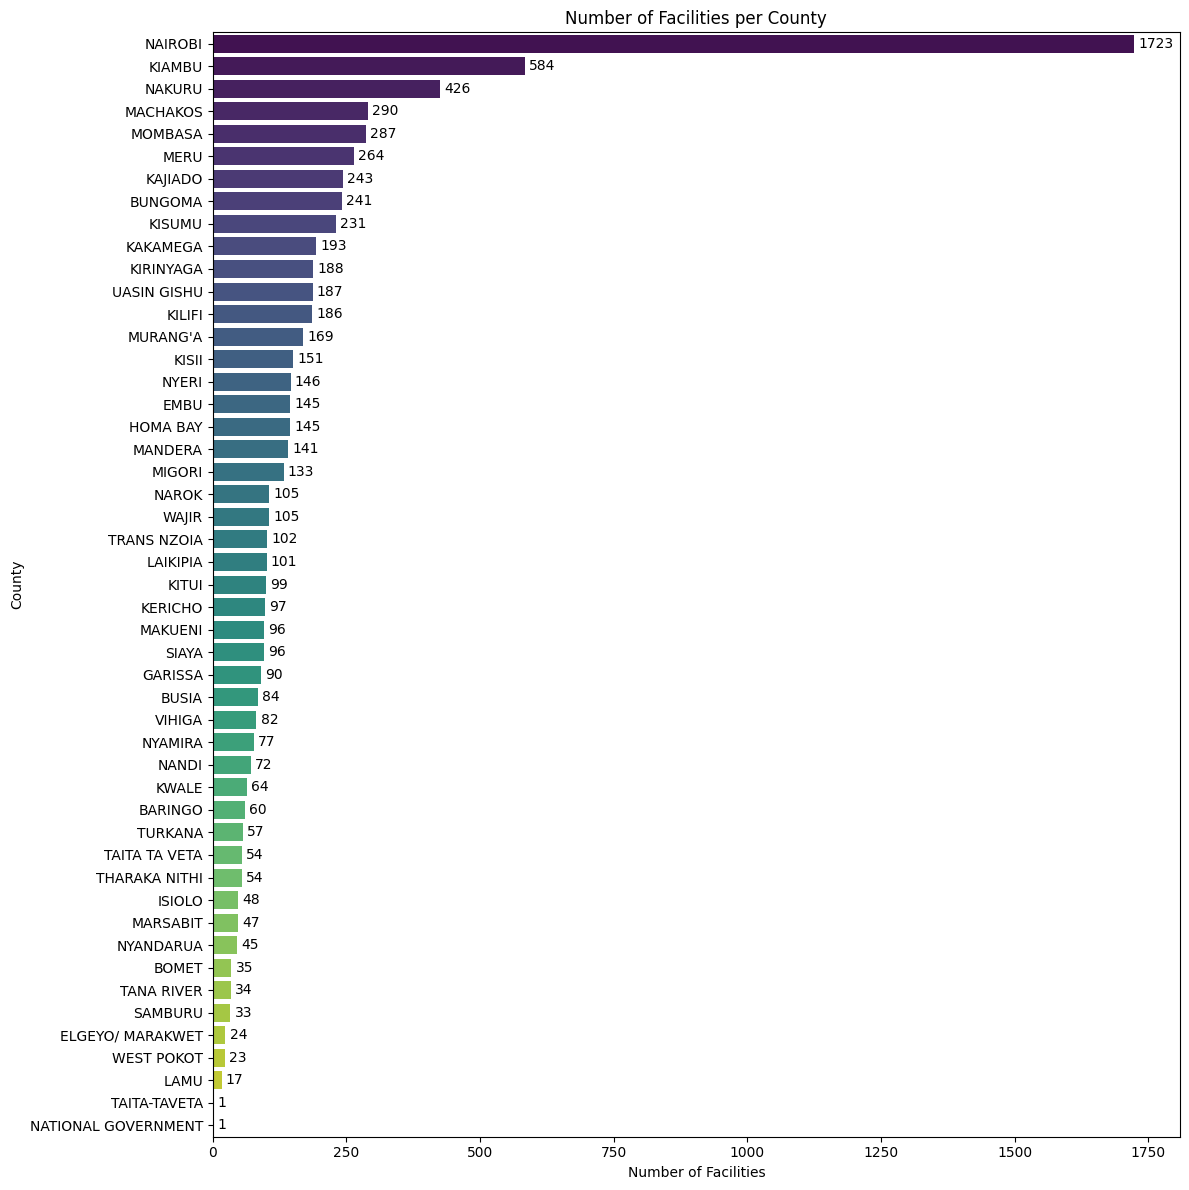

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts per county and sort
county_counts = df['County'].value_counts().reset_index()
county_counts.columns = ['County', 'Count']

# Create the bar chart
plt.figure(figsize=(12, 12))
ax = sns.barplot(data=county_counts, y='County', x='Count', hue='County', palette='viridis', legend=False)

# Add numerical labels to the bars
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.title('Number of Facilities per County')
plt.xlabel('Number of Facilities')
plt.ylabel('County')
plt.tight_layout()
plt.show()

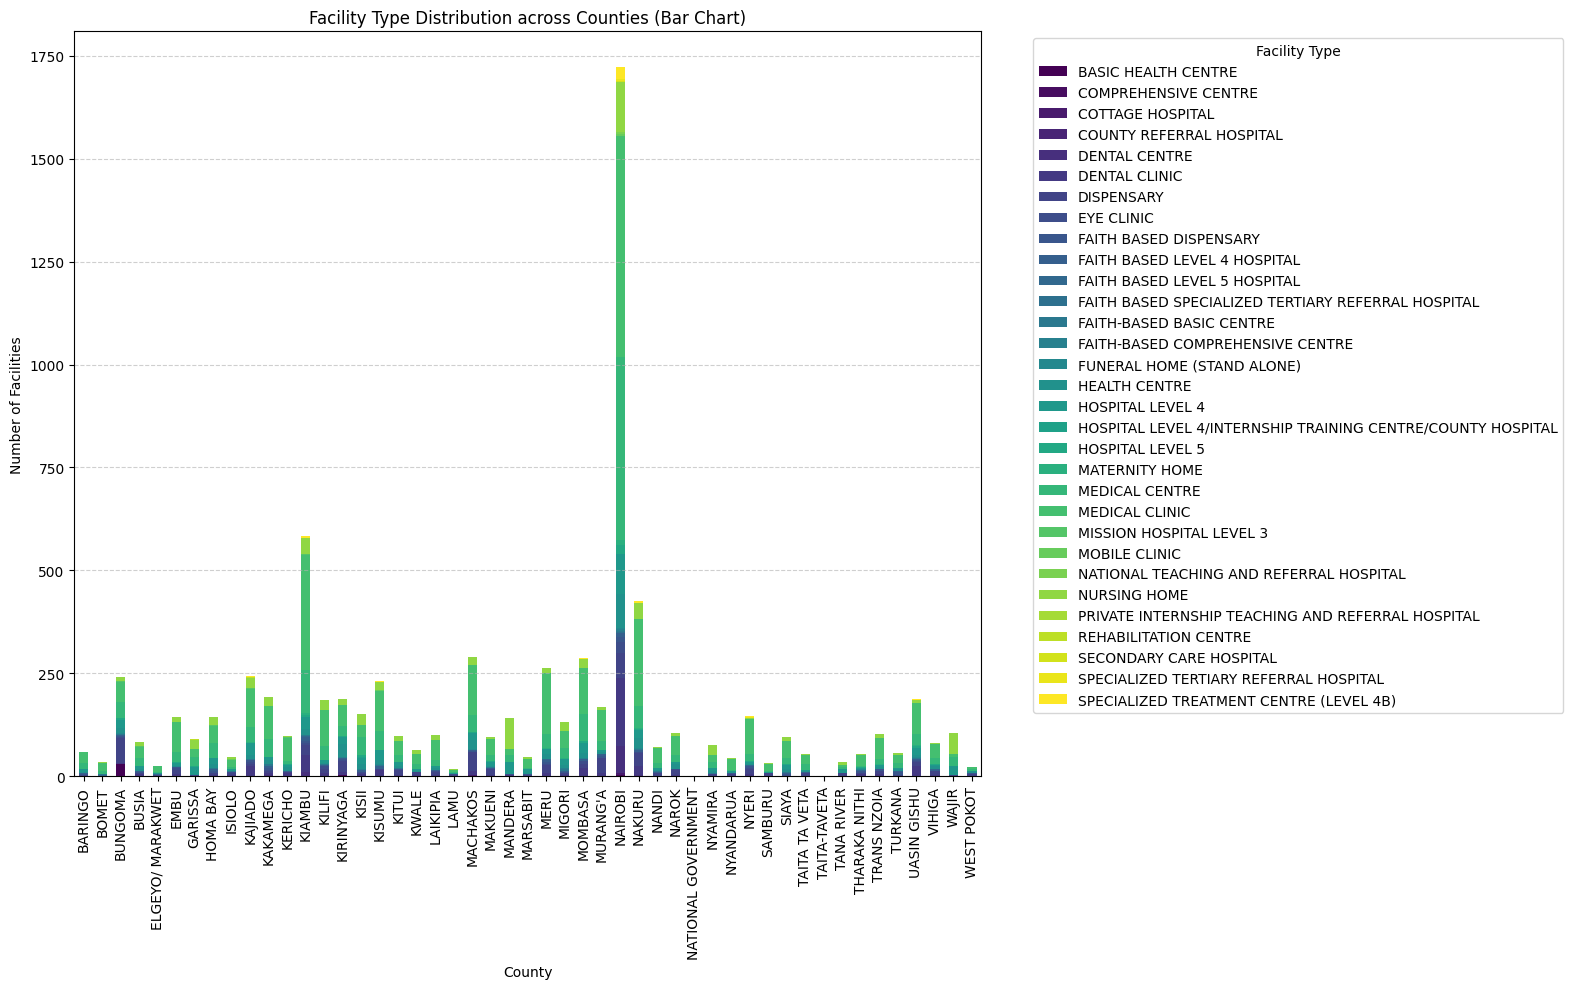

In [9]:
# Pivot data to get counts of Facility_Type per County
pivot_df = df.groupby(['County', 'Facility_Type']).size().unstack(fill_value=0)

# Plotting as a stacked bar chart
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(16, 10), colormap='viridis')

plt.title('Facility Type Distribution across Counties (Bar Chart)')
plt.xlabel('County')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=90)
plt.legend(title='Facility Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

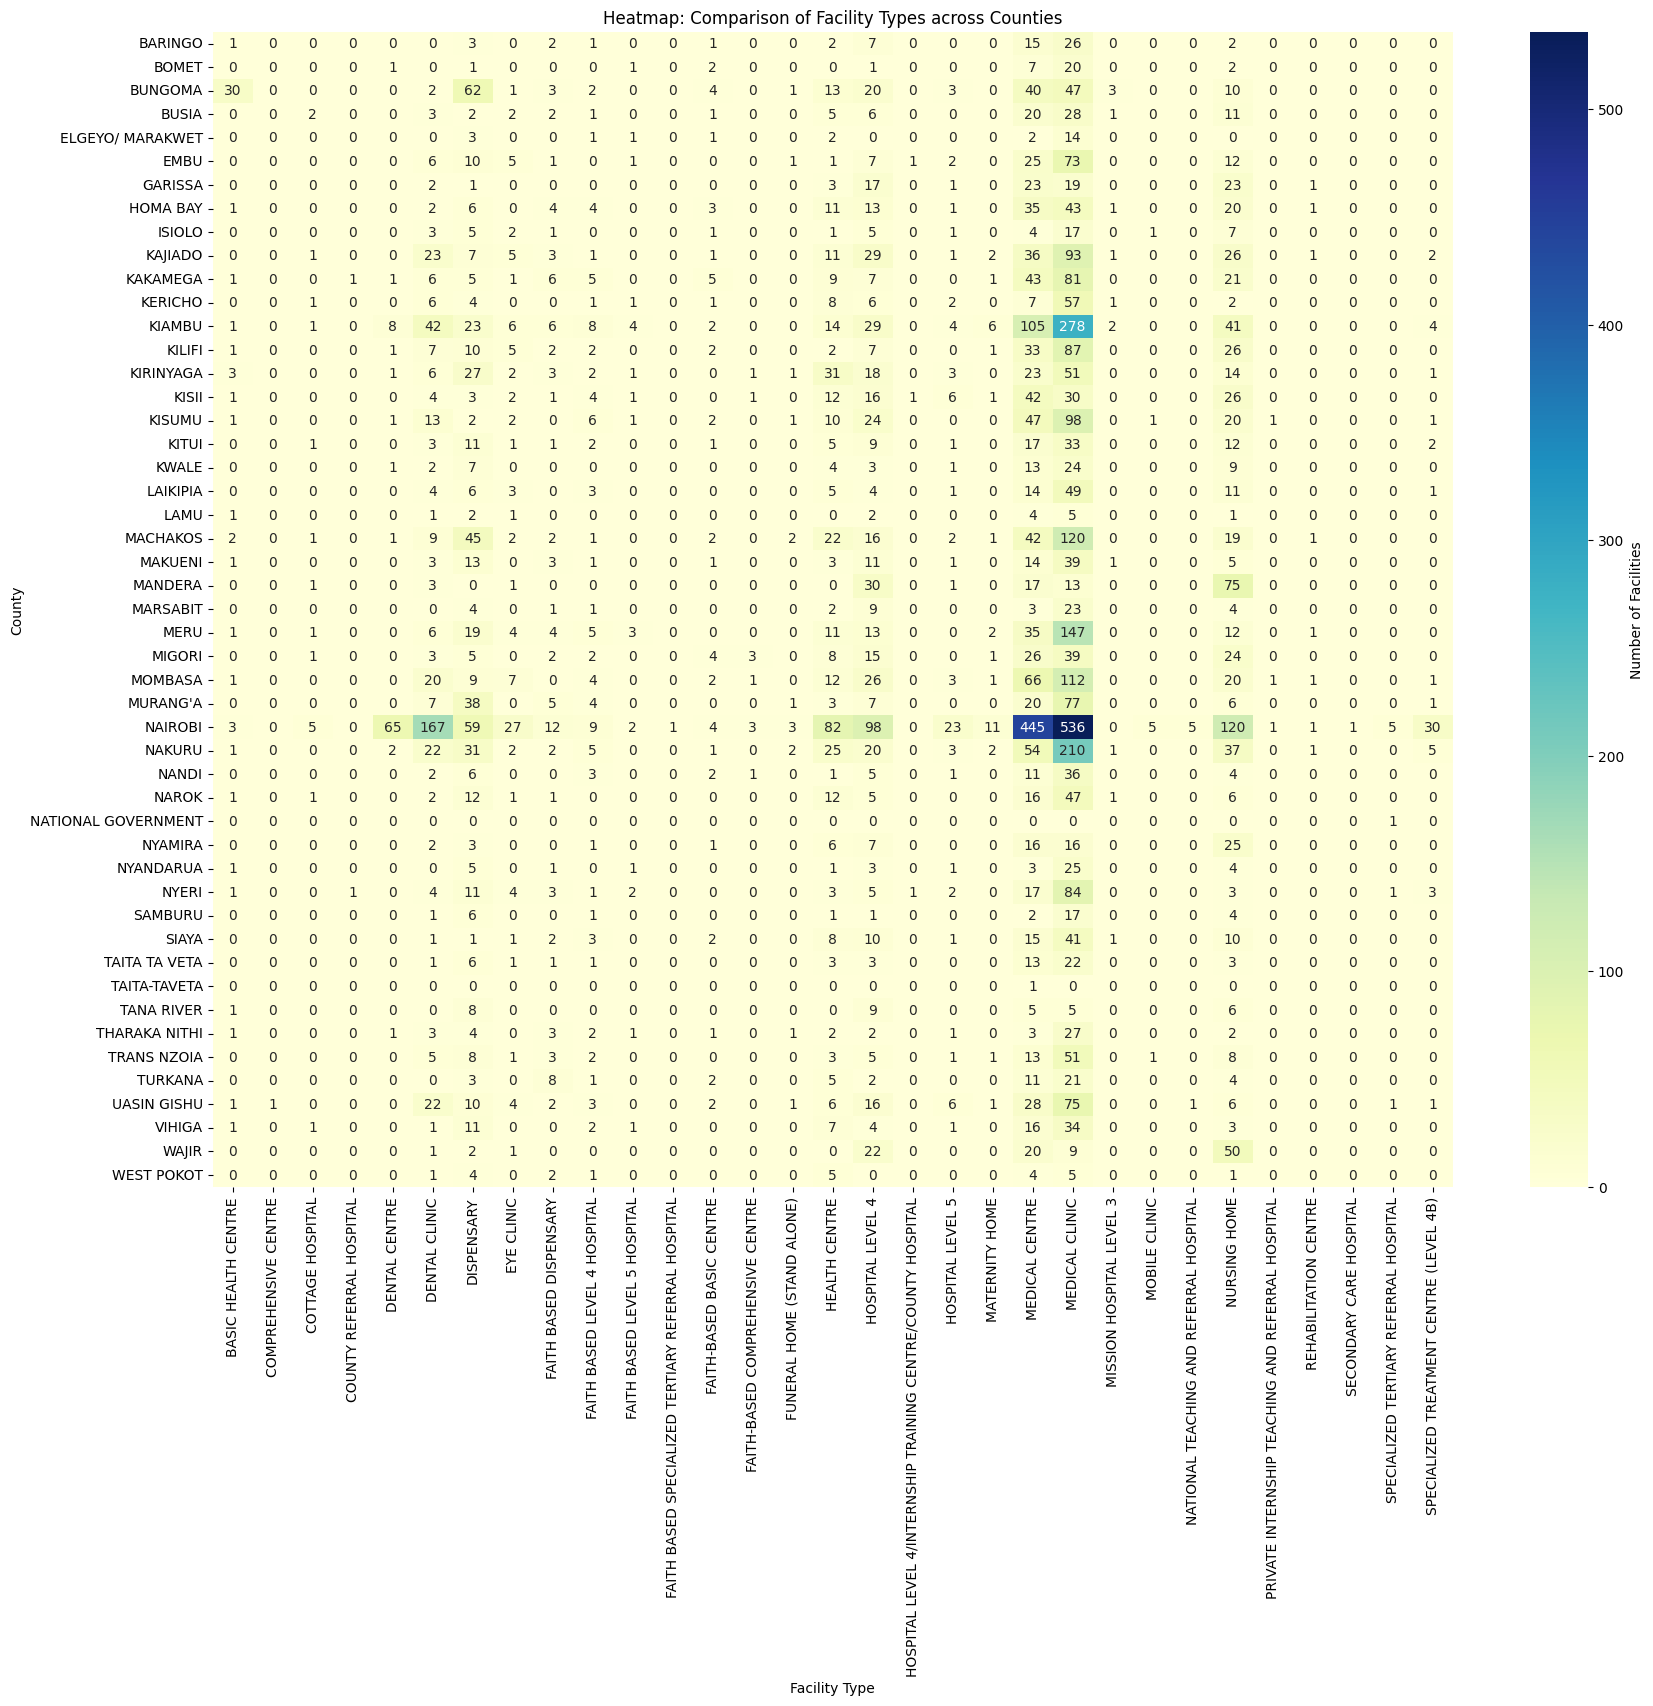

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the pivot_df using a heatmap for easier comparison
plt.figure(figsize=(20, 15))
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Facilities'})

plt.title('Heatmap: Comparison of Facility Types across Counties')
plt.xlabel('Facility Type')
plt.ylabel('County')
plt.show()

This heatmap allows for a direct comparison of healthcare infrastructure. For instance, you can easily spot which counties have a high density of specific facility types like 'MEDICAL CLINIC' or where specialized services like 'DIALYSIS CENTRE' are concentrated.

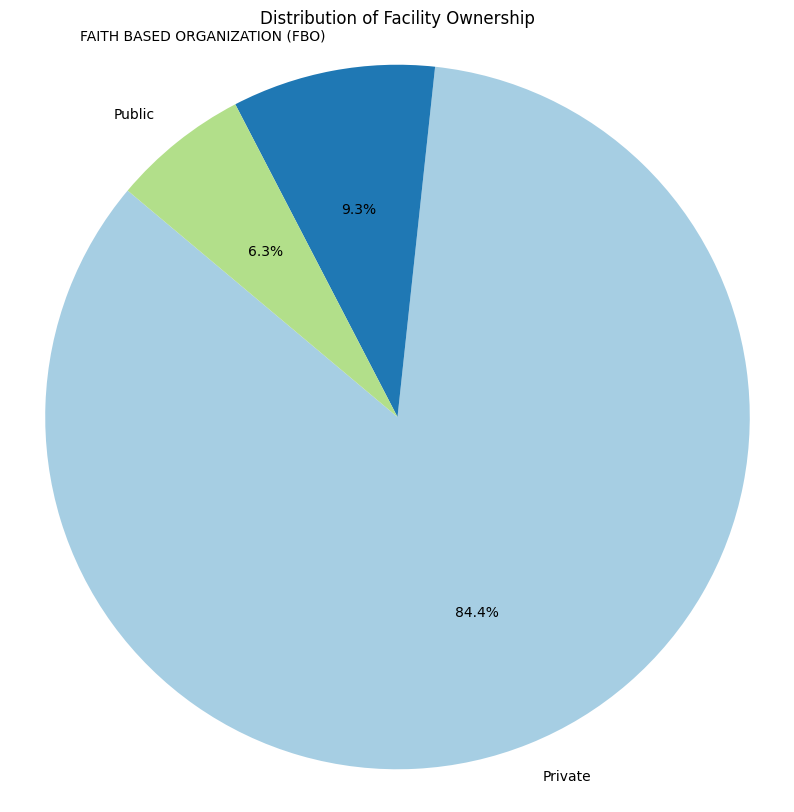

In [10]:
import matplotlib.pyplot as plt

# Calculate counts for facility ownership
ownership_counts = df['Facility_Ownership'].value_counts()

# Create a pie chart
plt.figure(figsize=(10, 10))
plt.pie(ownership_counts, labels=ownership_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Facility Ownership')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

# Split the preprocessed data into training (70%) and testing (30%) sets
# We'll use kmeans_labels as a dummy target for the split demonstration
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, kmeans_labels, test_size=0.3, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (5513, 12)
Testing set shape: (2363, 12)


In [16]:
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Prepare features: Using Bed_Capacity and Facility_Ownership for clustering
features = ['Bed_Capacity', 'Facility_Ownership', 'Level']
X = df[features]

# Preprocessing: Standardize numerical and One-Hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Bed_Capacity']),
        ('cat', OneHotEncoder(), ['Facility_Ownership', 'Level'])
    ])

X_processed = preprocessor.fit_transform(X).toarray()

# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

print("Data preprocessed and PCA reduction complete.")

Data preprocessed and PCA reduction complete.


In [17]:
# Re-executing clustering on the split datasets

# 1. K-Means (Fit on Train, Predict on Test)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_train)
kmeans_test_labels = kmeans.predict(X_test)

# 2. DBSCAN (DBSCAN doesn't have a separate predict, so we fit_predict on X_test)
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_test_labels = dbscan.fit_predict(X_test)

# 3. Hierarchical Clustering (Agglomerative - fit_predict on X_test)
hierarchical = AgglomerativeClustering(n_clusters=4)
hierarchical_test_labels = hierarchical.fit_predict(X_test)

# 4. Gaussian Mixture Model (Fit on Train, Predict on Test)
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_train)
gmm_test_labels = gmm.predict(X_test)

# Prepare PCA for the test set for visualization
pca_test = PCA(n_components=2)
X_test_pca = pca_test.fit_transform(X_test)

print("Algorithms executed using the split datasets. Visualization updated below.")

Algorithms executed using the split datasets. Visualization updated below.


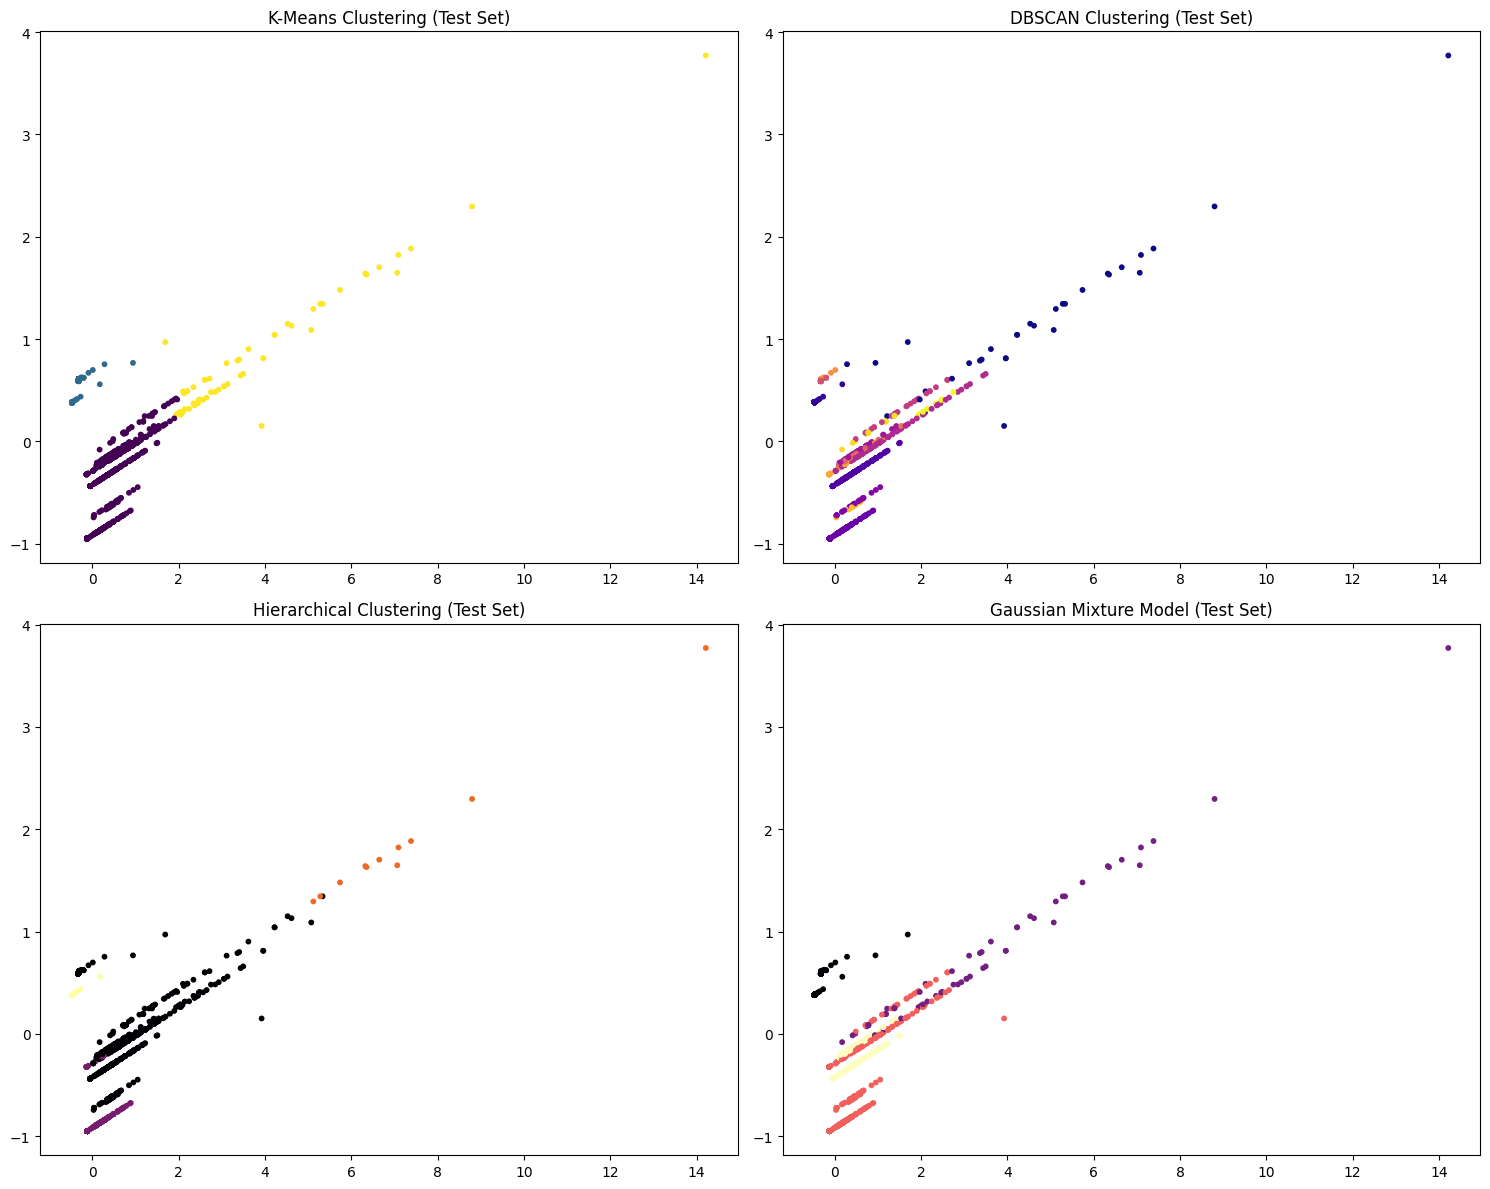

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot K-Means (Test Set)
axes[0, 0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=kmeans_test_labels, cmap='viridis', s=10)
axes[0, 0].set_title('K-Means Clustering (Test Set)')

# Plot DBSCAN (Test Set)
axes[0, 1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=dbscan_test_labels, cmap='plasma', s=10)
axes[0, 1].set_title('DBSCAN Clustering (Test Set)')

# Plot Hierarchical (Test Set)
axes[1, 0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=hierarchical_test_labels, cmap='inferno', s=10)
axes[1, 0].set_title('Hierarchical Clustering (Test Set)')

# Plot GMM (Test Set)
axes[1, 1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=gmm_test_labels, cmap='magma', s=10)
axes[1, 1].set_title('Gaussian Mixture Model (Test Set)')

plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

# Filter out noise for DBSCAN silhouette calculation (if any)
dbscan_mask = dbscan_test_labels != -1

scores = {
    'K-Means': silhouette_score(X_test, kmeans_test_labels),
    'GMM': silhouette_score(X_test, gmm_test_labels),
    'Hierarchical': silhouette_score(X_test, hierarchical_test_labels)
}

# Add DBSCAN only if it found clusters other than noise
if len(set(dbscan_test_labels)) > (1 if -1 in dbscan_test_labels else 0):
    scores['DBSCAN (Excluding Noise)'] = silhouette_score(X_test[dbscan_mask], dbscan_test_labels[dbscan_mask])

# Display scores
print("Silhouette Scores (Higher is better):")
for model, score in scores.items():
    print(f"{model}: {score:.4f}")

Silhouette Scores (Higher is better):
K-Means: 0.5361
GMM: 0.6157
Hierarchical: 0.6147
DBSCAN (Excluding Noise): 0.8833


### Investigating DBSCAN Noise Points
Noise points represent facilities that are statistically different from the main groups. Let's look at their raw data.

In [21]:
import pandas as pd

# Map the test set indices back to the original dataframe
# Since we used train_test_split, we can find the indices from the split
_, X_test_df_indices = train_test_split(df.index, test_size=0.3, random_state=42)

# Create a temporary dataframe for the test set results
test_results = df.loc[X_test_df_indices].copy()
test_results['DBSCAN_Cluster'] = dbscan_test_labels

# Filter for noise points (-1)
noise_points = test_results[test_results['DBSCAN_Cluster'] == -1]

print(f"Number of noise points identified: {len(noise_points)}")
print("\nSample of facilities flagged as noise:")
display(noise_points[['Facility_Name', 'Facility_Ownership', 'Level', 'Bed_Capacity', 'County']].head(10))

# Summary of noise point characteristics
print("\nStatistical Summary of Noise Points Bed Capacity:")
display(noise_points['Bed_Capacity'].describe())

Number of noise points identified: 33

Sample of facilities flagged as noise:


,Facility_Name,Facility_Ownership,Level,Bed_Capacity,County
2229,KERUGOYA COUNTY REFERRAL HOSPITAL,Public,LEVEL 5,250,KIRINYAGA
6862,NORTH KINANGOP CATHOLIC HOSPITAL,FAITH BASED ORGANIZATION (FBO),LEVEL 5,309,NYANDARUA
7688,JUMUIA FRIENDS HOSPITAL KAIMOSI,FAITH BASED ORGANIZATION (FBO),LEVEL 5,100,VIHIGA
2521,ST. JOSEPH'S HOSPITAL NYABONDO,FAITH BASED ORGANIZATION (FBO),LEVEL 5,150,KISUMU
1452,AIC CURE INTERNATIONAL HOSPITAL,FAITH BASED ORGANIZATION (FBO),LEVEL 5,56,KIAMBU
5371,LIFEBRIDGE COTTAGE HOSPITAL LIMITED,Private,LEVEL 4B,110,NAIROBI
6301,BENTA AND LEON HEALTHCARE LTD,Private,LEVEL 4B,56,NAKURU
7370,JOLICAGE HEALTH CENTRE,Private,LEVEL 2,107,TRANS NZOIA
3322,MAKUENI COUNTY REFERRAL HOSPITAL,Public,LEVEL 4,357,MAKUENI
682,HOMABAY COUNTY REFERRAL HOSPITAL,Public,LEVEL 5,311,HOMA BAY



Statistical Summary of Noise Points Bed Capacity:


,Bed_Capacity
count,33.000000
mean,219.909091
std,132.046716
min,30.000000
25%,126.000000
50%,200.000000
75%,280.000000
max,700.000000


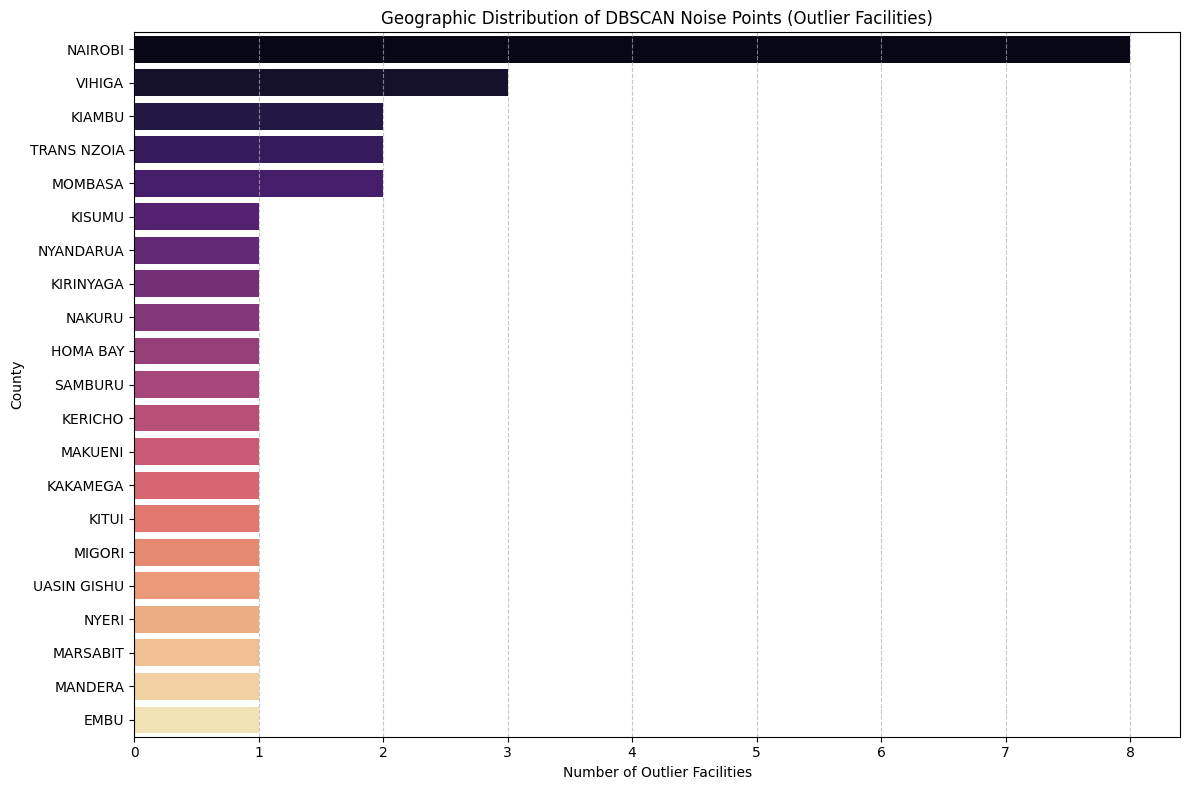

Top 5 Counties with highest percentage of outliers in the test set:
County
MARSABIT       11.111111
VIHIGA         10.344828
SAMBURU        10.000000
NYANDARUA       9.090909
TRANS NZOIA     5.405405
Name: count, dtype: float64


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate frequency of noise points per county
noise_county_counts = noise_points['County'].value_counts().reset_index()
noise_county_counts.columns = ['County', 'Noise_Count']

# Visualize the geographic distribution
plt.figure(figsize=(12, 8))
sns.barplot(data=noise_county_counts, x='Noise_Count', y='County', hue='County', palette='magma', legend=False)

plt.title('Geographic Distribution of DBSCAN Noise Points (Outlier Facilities)')
plt.xlabel('Number of Outlier Facilities')
plt.ylabel('County')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Provide a percentage context
total_test_by_county = test_results['County'].value_counts()
noise_pct = (noise_points['County'].value_counts() / total_test_by_county * 100).dropna().sort_values(ascending=False)

print("Top 5 Counties with highest percentage of outliers in the test set:")
print(noise_pct.head(5))

### Detailed Profiling of Top-Performing Clusters
We will analyze the clusters from GMM (best general partitioner) and DBSCAN (best at identifying dense similarities) to see what defines these groups.

In [23]:
import pandas as pd

# Adding cluster labels to our test results dataframe for analysis
test_results['GMM_Cluster'] = gmm_test_labels

# Group by GMM clusters to see average bed capacity and most frequent level/ownership
gmm_profile = test_results.groupby('GMM_Cluster').agg({
    'Bed_Capacity': ['mean', 'median', 'max'],
    'Level': lambda x: x.mode()[0],
    'Facility_Ownership': lambda x: x.mode()[0],
    'Facility_Name': 'count'
}).rename(columns={'Facility_Name': 'Facility_Count'})

print("--- GMM Cluster Profiles ---")
display(gmm_profile)

# Group by DBSCAN clusters (excluding noise)
dbscan_profile = test_results[test_results['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').agg({
    'Bed_Capacity': ['mean', 'max'],
    'Level': lambda x: x.mode()[0],
    'Facility_Ownership': lambda x: x.mode()[0],
    'Facility_Name': 'count'
}).rename(columns={'Facility_Name': 'Facility_Count'})

print("\n--- DBSCAN Dense Cluster Profiles (Excluding Noise) ---")
display(dbscan_profile.head())


--- GMM Cluster Profiles ---


Bed_Capacity                 Level Facility_Ownership  \
                    mean median  max  <lambda>           <lambda>   
GMM_Cluster                                                         
0               0.250801    0.0  107   LEVEL 2            Private   
1             149.828125  126.5  700   LEVEL 4             Public   
2              18.141457   10.0  200  LEVEL 3A            Private   
3              22.151335   20.0   77  LEVEL 3B            Private   

            Facility_Count  
                     count  
GMM_Cluster                 
0                     1248  
1                       64  
2                      714  
3                      337


--- DBSCAN Dense Cluster Profiles (Excluding Noise) ---


Bed_Capacity         Level              Facility_Ownership  \
                       mean max  <lambda>                        <lambda>   
DBSCAN_Cluster                                                              
0                  0.050326  32   LEVEL 2                         Private   
1                 23.633205  77  LEVEL 3B                         Private   
2                  6.612836  50  LEVEL 3A                         Private   
3                 19.200000  50  LEVEL 3A  FAITH BASED ORGANIZATION (FBO)   
4                 20.325581  65  LEVEL 3B  FAITH BASED ORGANIZATION (FBO)   

               Facility_Count  
                        count  
DBSCAN_Cluster                 
0                        1073  
1                         259  
2                         483  
3                          30  
4                          43

### Bed Capacity Distribution by GMM Cluster
We'll use a boxplot to see the range and outliers of bed capacity within each group defined by the Gaussian Mixture Model.

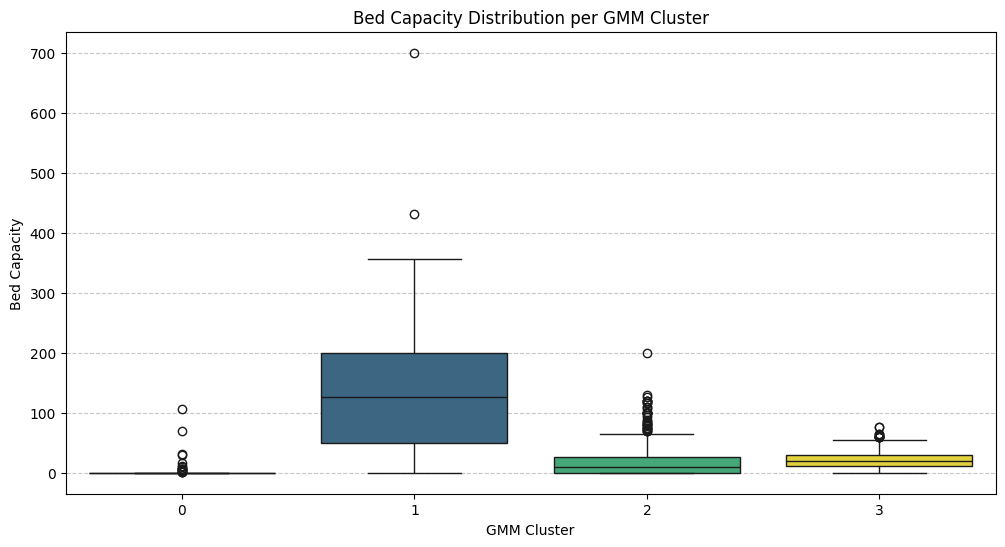

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=test_results, x='GMM_Cluster', y='Bed_Capacity', hue='GMM_Cluster', palette='viridis', legend=False)

plt.title('Bed Capacity Distribution per GMM Cluster')
plt.xlabel('GMM Cluster')
plt.ylabel('Bed Capacity')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-axis to see the bulk of the data more clearly if there are extreme outliers
# plt.ylim(-5, 300)

plt.show()

For a more detailed look at the density of these distributions, let's also view a violin plot.

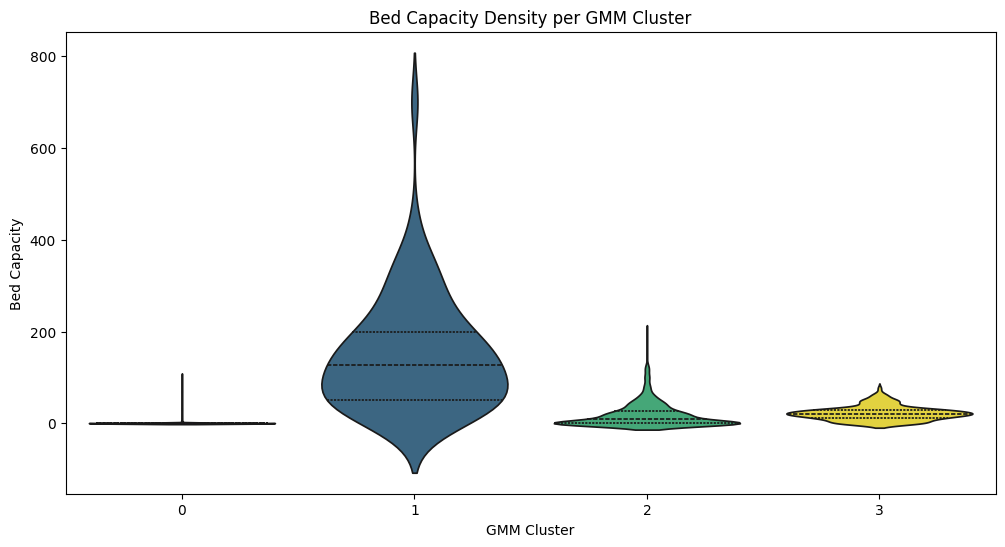

In [25]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=test_results, x='GMM_Cluster', y='Bed_Capacity', hue='GMM_Cluster', palette='viridis', inner='quart', legend=False)

plt.title('Bed Capacity Density per GMM Cluster')
plt.xlabel('GMM Cluster')
plt.ylabel('Bed Capacity')
plt.show()

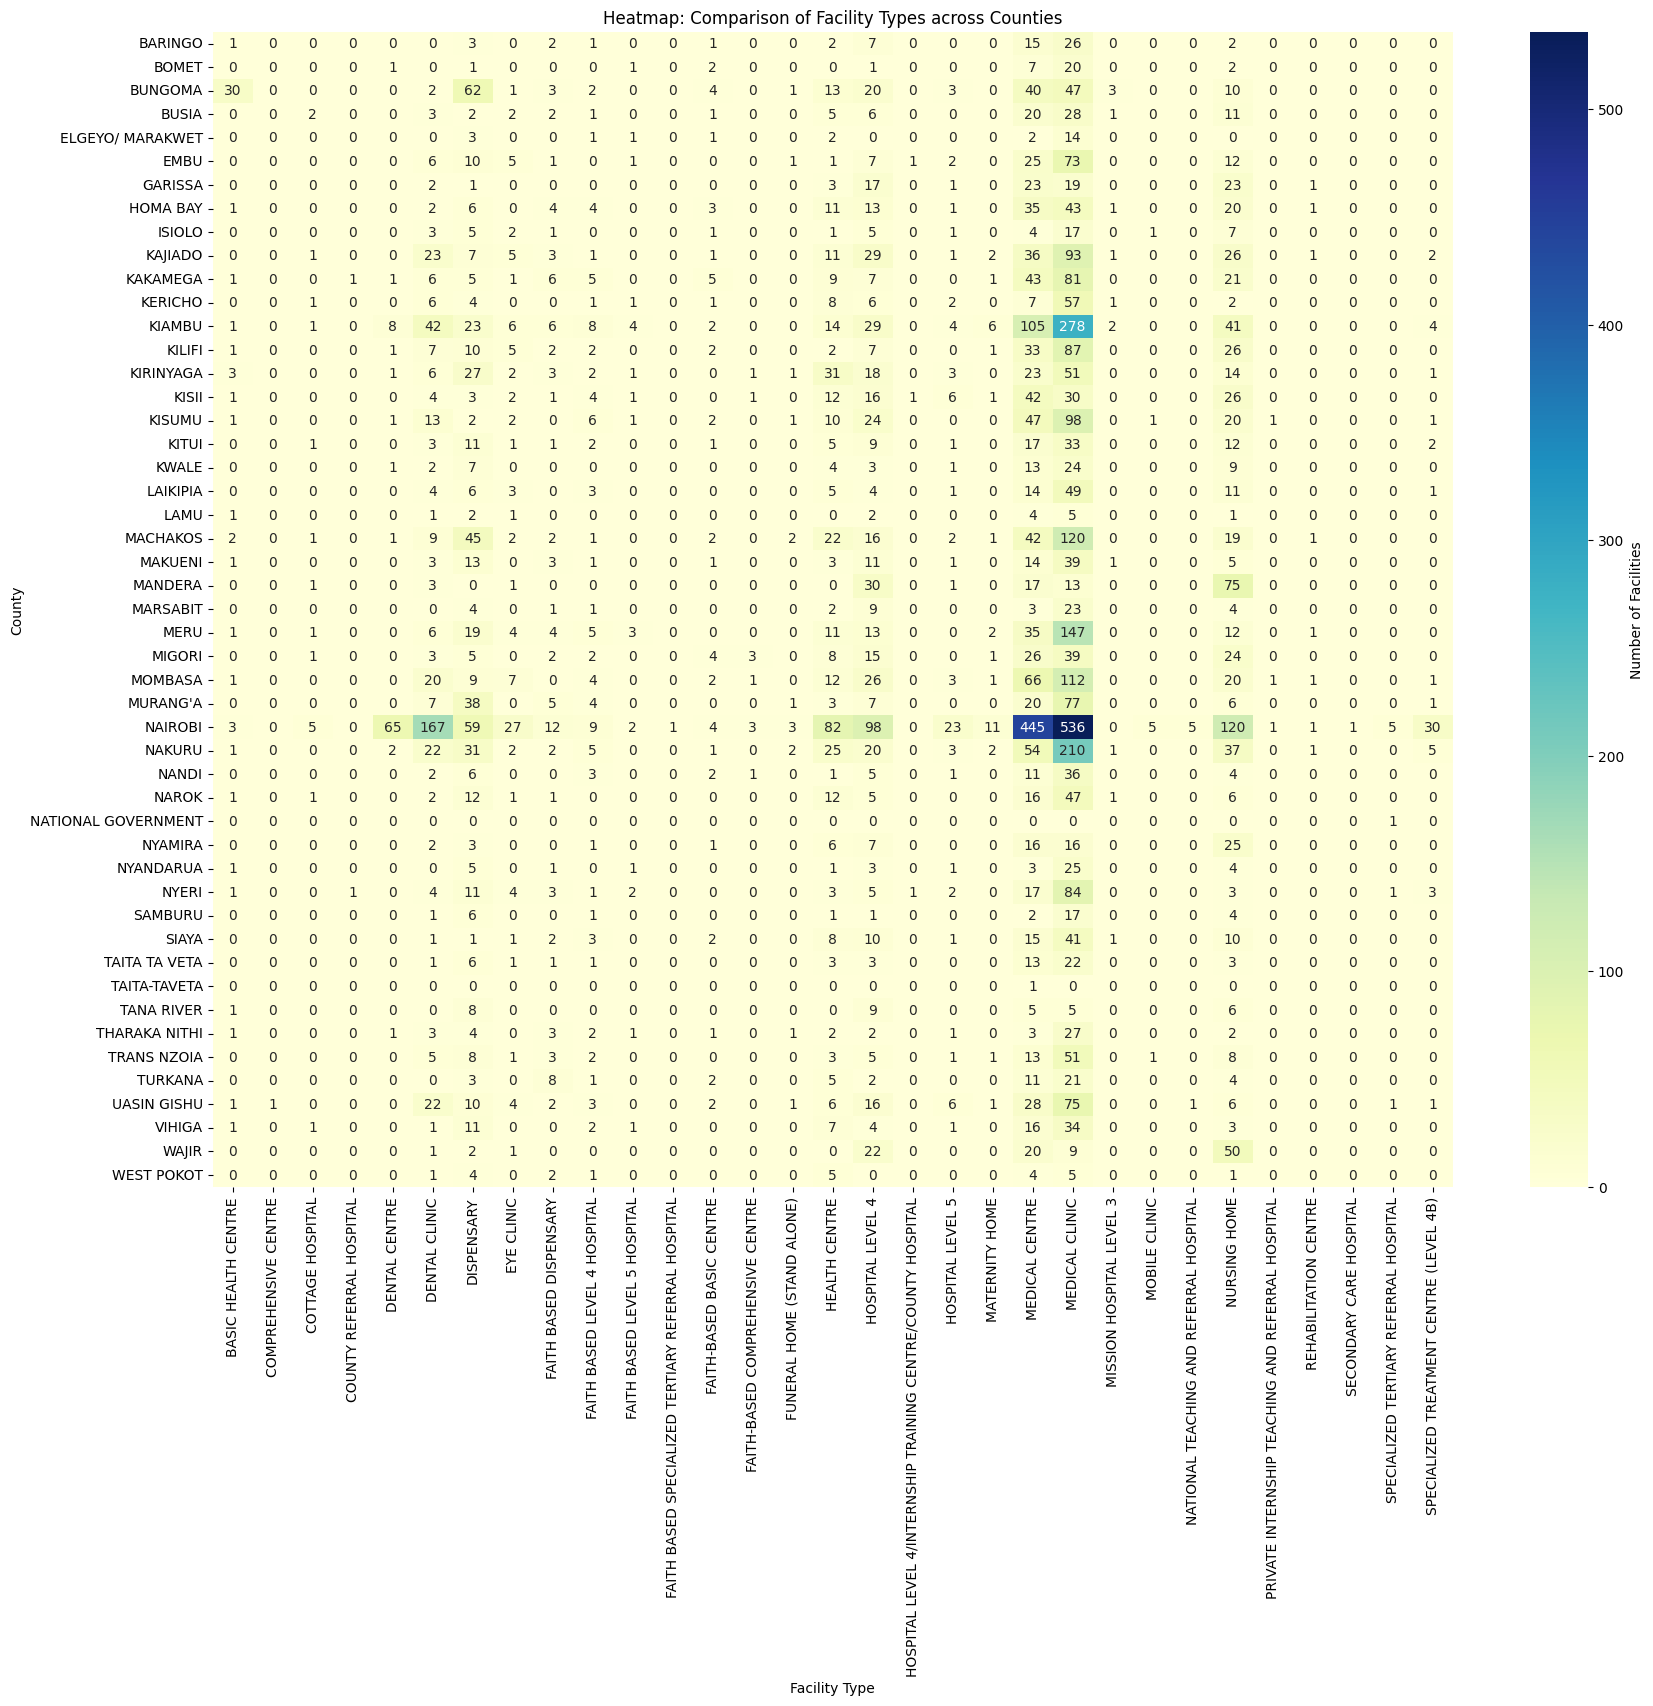

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the pivot_df using a heatmap for easier comparison across counties
plt.figure(figsize=(20, 15))
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Facilities'})

plt.title('Heatmap: Comparison of Facility Types across Counties')
plt.xlabel('Facility Type')
plt.ylabel('County')
plt.show()

### Predicting Facility Level
We will use a Random Forest Classifier to predict the `Level` of a facility based on its `Bed_Capacity` and `Facility_Type`.

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare features and target
clf_features = ['Bed_Capacity', 'Facility_Type']
clf_target = 'Level'

X_clf = df[clf_features]
y_clf = df[clf_target]

# Preprocessing
clf_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Bed_Capacity']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Facility_Type'])
    ])

# Split data (70% train, 30% test)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42
)

# Fit preprocessor and transform data
X_train_clf_proc = clf_preprocessor.fit_transform(X_train_clf)
X_test_clf_proc = clf_preprocessor.transform(X_test_clf)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_clf_proc, y_train_clf)

# Make predictions
y_pred_clf = rf_model.predict(X_test_clf_proc)

# Evaluate the model
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

Model Accuracy: 0.9992

Classification Report:
              precision    recall  f1-score   support

     LEVEL 2       1.00      1.00      1.00      1248
    LEVEL 3A       1.00      1.00      1.00       527
    LEVEL 3B       1.00      1.00      1.00       337
     LEVEL 4       1.00      1.00      1.00       200
    LEVEL 4B       1.00      1.00      1.00        21
     LEVEL 5       1.00      1.00      1.00        27
    LEVEL 6A       1.00      1.00      1.00         1
    LEVEL 6B       1.00      1.00      1.00         2

    accuracy                           1.00      2363
   macro avg       1.00      1.00      1.00      2363
weighted avg       1.00      1.00      1.00      2363



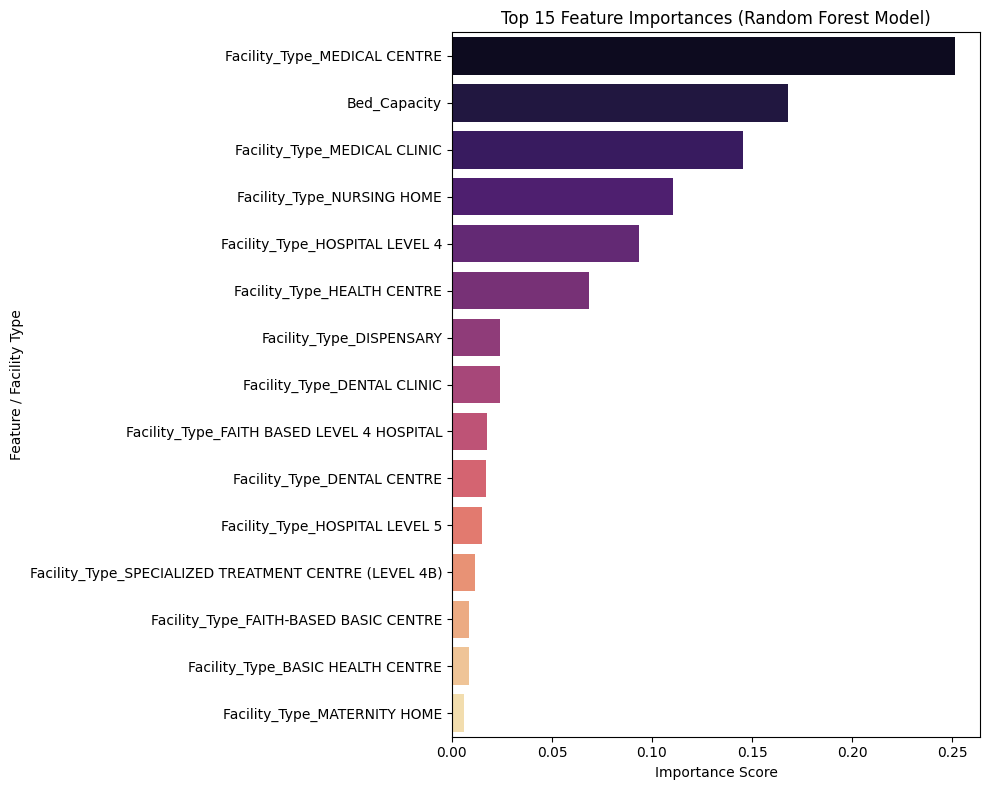

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the preprocessor
cat_feature_names = clf_preprocessor.named_transformers_['cat'].get_feature_names_out(['Facility_Type'])
feature_names = ['Bed_Capacity'] + list(cat_feature_names)

# Get importances from the model
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 15 most important features
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)

plt.title('Top 15 Feature Importances (Random Forest Model)')
plt.xlabel('Importance Score')
plt.ylabel('Feature / Facility Type')
plt.tight_layout()
plt.show()

In [30]:
!pip install hdbscan

In [33]:
from sklearn.cluster import OPTICS, MeanShift, SpectralClustering, AffinityPropagation, Birch
import hdbscan
import numpy as np

# 1. OPTICS
optics = OPTICS(min_samples=5)
optics_labels = optics.fit_predict(X_test)

# 2. Mean Shift
meanshift = MeanShift(bandwidth=None) # Automatically estimates bandwidth
meanshift_labels = meanshift.fit_predict(X_test)

# 3. Spectral Clustering
spectral = SpectralClustering(n_clusters=4, assign_labels='discretize', random_state=42)
spectral_labels = spectral.fit_predict(X_test)

# 4. Affinity Propagation
affinity = AffinityPropagation(random_state=42, damping=0.9)
affinity_labels = affinity.fit_predict(X_test)

# 5. BIRCH
birch = Birch(n_clusters=4)
birch_labels = birch.fit_predict(X_test)

# 6. HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=5)
hdb_labels = hdb.fit_predict(X_test)

print("Additional clustering algorithms executed successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_optics.py:1086: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


Additional clustering algorithms executed successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


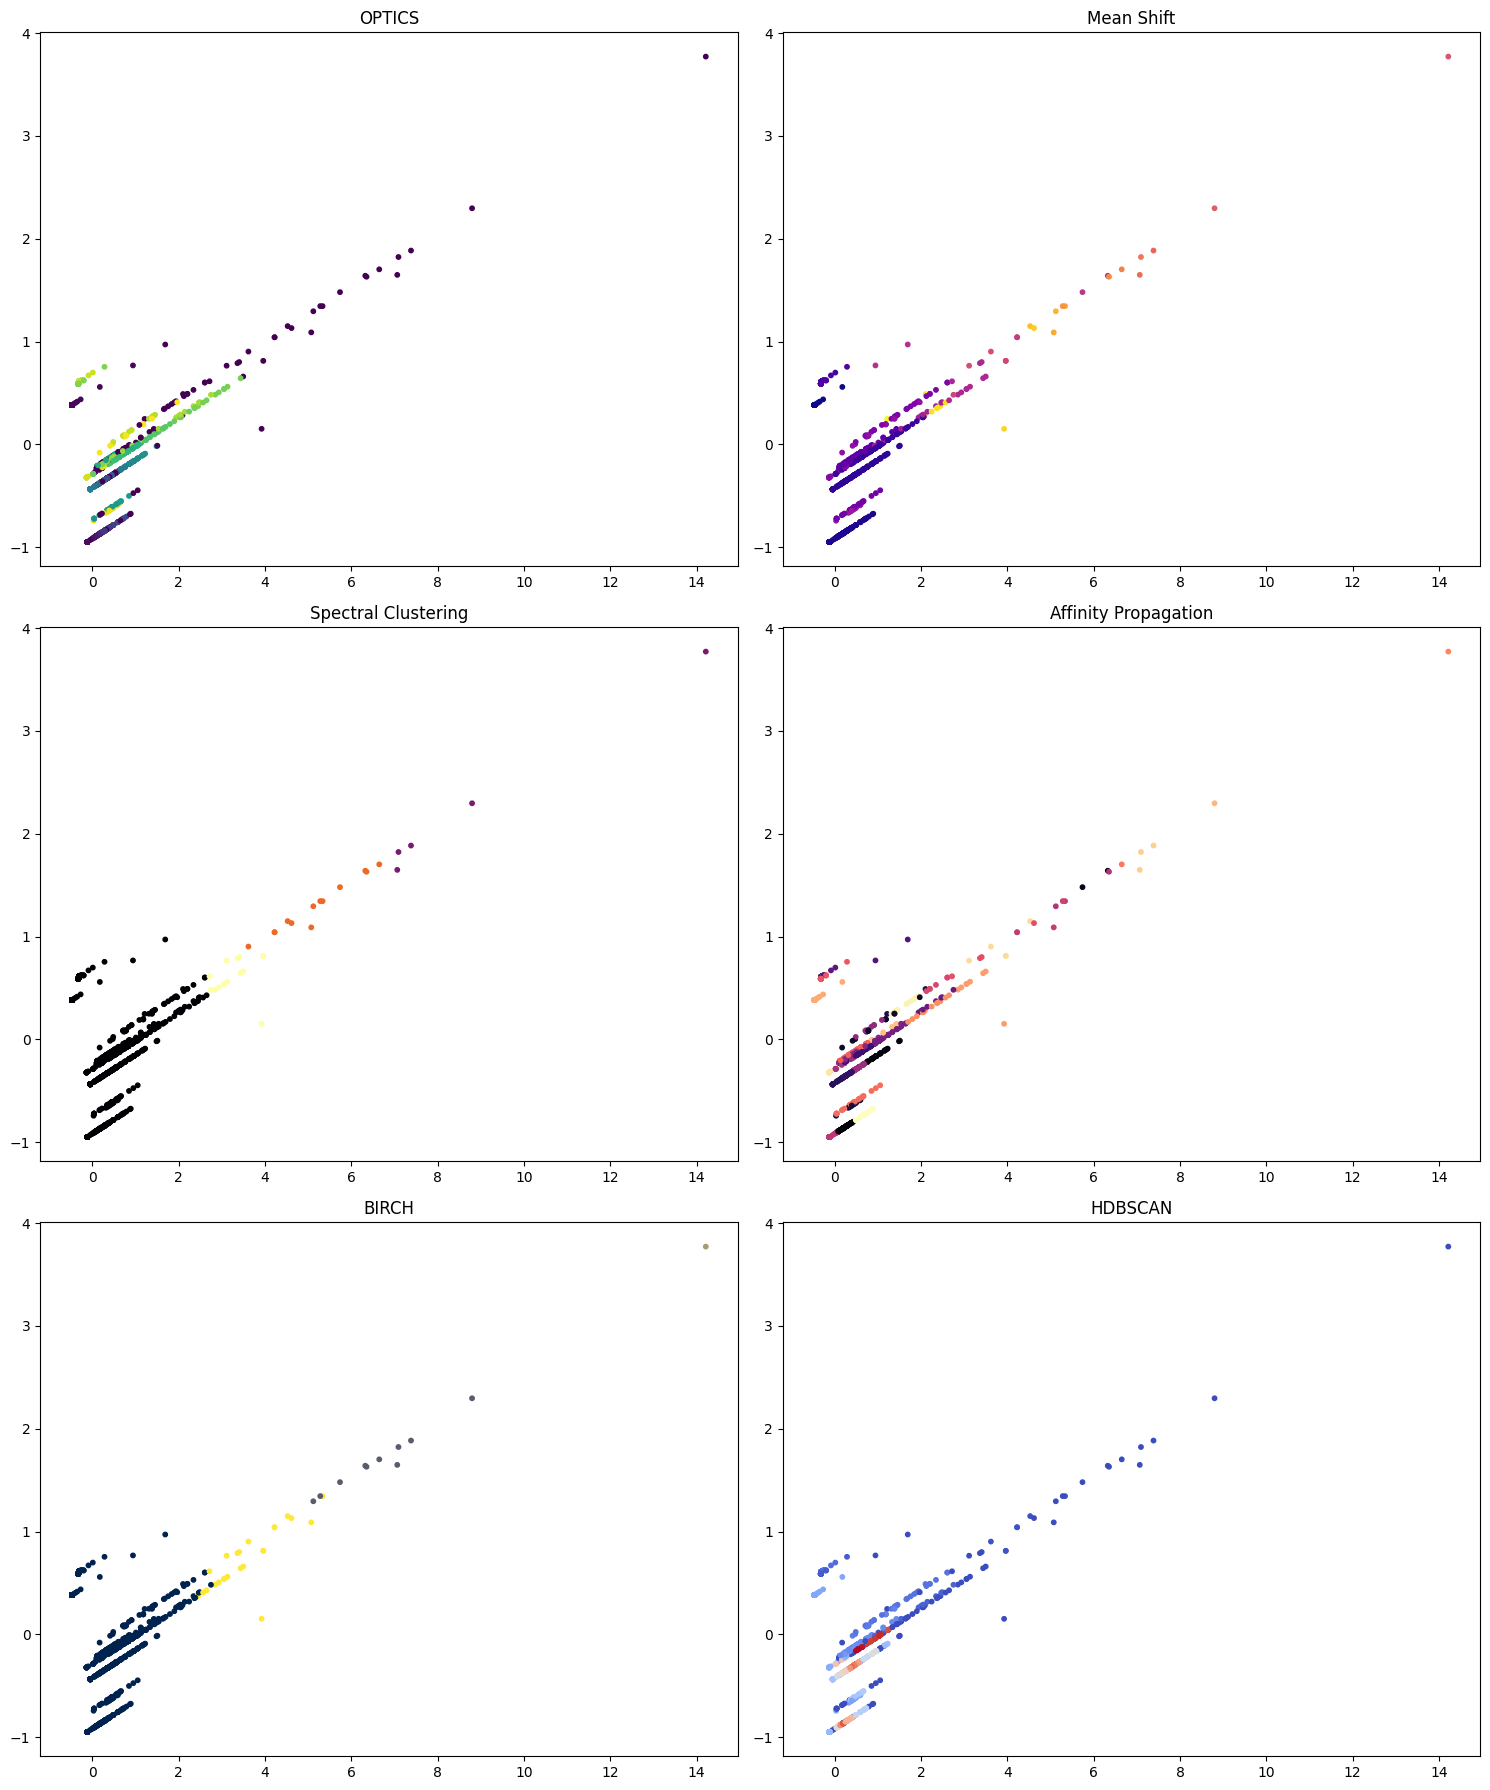

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Plot OPTICS
axes[0, 0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=optics_labels, cmap='viridis', s=10)
axes[0, 0].set_title('OPTICS')

# Plot Mean Shift
axes[0, 1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=meanshift_labels, cmap='plasma', s=10)
axes[0, 1].set_title('Mean Shift')

# Plot Spectral
axes[1, 0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=spectral_labels, cmap='inferno', s=10)
axes[1, 0].set_title('Spectral Clustering')

# Plot Affinity Propagation
axes[1, 1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=affinity_labels, cmap='magma', s=10)
axes[1, 1].set_title('Affinity Propagation')

# Plot BIRCH
axes[2, 0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=birch_labels, cmap='cividis', s=10)
axes[2, 0].set_title('BIRCH')

# Plot HDBSCAN
axes[2, 1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=hdb_labels, cmap='coolwarm', s=10)
axes[2, 1].set_title('HDBSCAN')

plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import silhouette_score

# Initialize a dictionary for the new scores
new_scores = {}

# Helper to calculate score excluding noise (label -1)
def calculate_score_no_noise(X, labels):
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        return silhouette_score(X[mask], labels[mask])
    return None

# Calculate scores for each new algorithm
new_scores['OPTICS (Excluding Noise)'] = calculate_score_no_noise(X_test, optics_labels)
new_scores['Mean Shift'] = silhouette_score(X_test, meanshift_labels)
new_scores['Spectral Clustering'] = silhouette_score(X_test, spectral_labels)
new_scores['Affinity Propagation'] = silhouette_score(X_test, affinity_labels)
new_scores['BIRCH'] = silhouette_score(X_test, birch_labels)
new_scores['HDBSCAN (Excluding Noise)'] = calculate_score_no_noise(X_test, hdb_labels)

# Display the results
print("--- Silhouette Scores for New Algorithms ---")
for model, score in new_scores.items():
    if score is not None:
        print(f"{model}: {score:.4f}")
    else:
        print(f"{model}: Insufficient clusters found")

--- Silhouette Scores for New Algorithms ---
OPTICS (Excluding Noise): 0.9578
Mean Shift: 0.8770
Spectral Clustering: 0.6469
Affinity Propagation: 0.8599
BIRCH: 0.6713
HDBSCAN (Excluding Noise): 0.9477


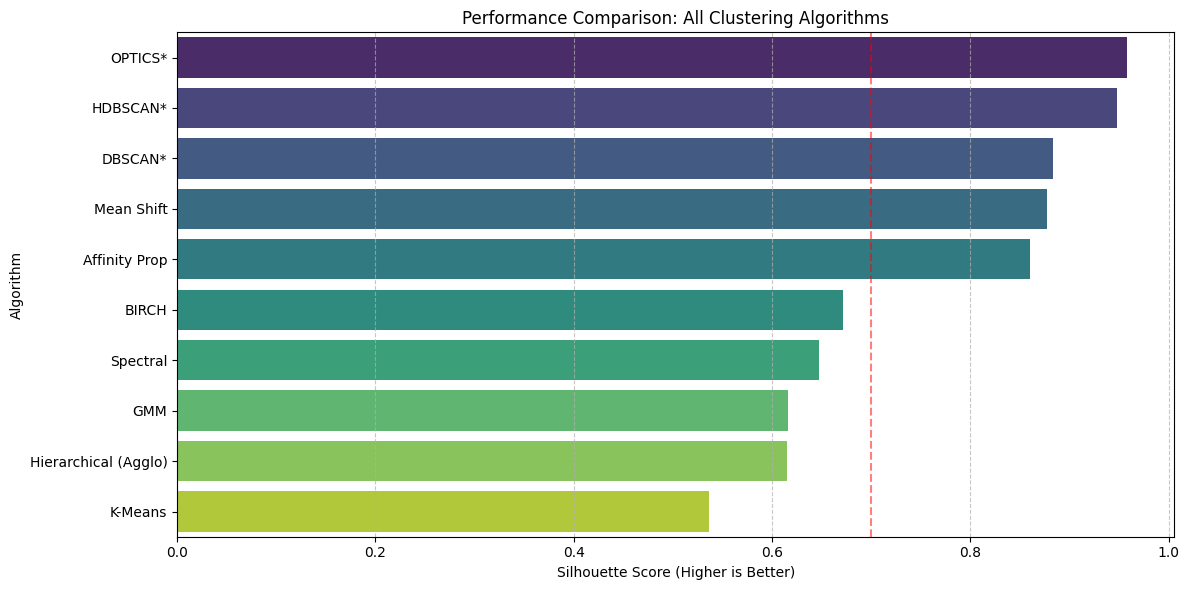

* Denotes scores calculated excluding noise points for density-based algorithms.


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine initial and new scores
all_model_scores = {
    'K-Means': 0.5361,
    'GMM': 0.6157,
    'Hierarchical (Agglo)': 0.6147,
    'DBSCAN*': 0.8833,
    'OPTICS*': 0.9578,
    'Mean Shift': 0.8770,
    'Spectral': 0.6469,
    'Affinity Prop': 0.8599,
    'BIRCH': 0.6713,
    'HDBSCAN*': 0.9477
}

# Convert to DataFrame for plotting
score_df = pd.DataFrame(list(all_model_scores.items()), columns=['Algorithm', 'Silhouette Score']).sort_values(by='Silhouette Score', ascending=False)

# Visualize comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=score_df, x='Silhouette Score', y='Algorithm', hue='Algorithm', palette='viridis', legend=False)
plt.title('Performance Comparison: All Clustering Algorithms')
plt.xlabel('Silhouette Score (Higher is Better)')
plt.ylabel('Algorithm')
plt.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='High Performance Threshold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("* Denotes scores calculated excluding noise points for density-based algorithms.")

--- Mean Shift Cluster Profiles ---


Bed_Capacity                 Level  \
                          mean median  max  <lambda>   
MeanShift_Cluster                                      
0                     0.050326    0.0   32   LEVEL 2   
1                     6.612836    0.0   50  LEVEL 3A   
2                    23.633205   22.0   77  LEVEL 3B   
3                    43.320896   40.0  101   LEVEL 4   
4                     0.330097    0.0   16   LEVEL 2   
5                     0.685714    0.0   30   LEVEL 2   
6                    20.325581   16.0   65  LEVEL 3B   
7                    13.428571   12.0   45  LEVEL 3B   
8                    19.200000   20.0   50  LEVEL 3A   
9                    68.040000   63.0  120   LEVEL 4   
10                   14.400000   10.0   56  LEVEL 4B   
11                   37.882353   30.0   89   LEVEL 4   
12                   18.461538   18.0   28  LEVEL 3A   
13                   87.000000  100.0  127   LEVEL 5   
14                  150.272727  150.0  172   LEVEL 4   
15                   88.500000   88.5  107   LEVEL 2   
16                  294.500000  294.5  309   LEVEL 5   
17                  200.000000  200.0  200   LEVEL 4   
18                  180.000000  200.0  200   LEVEL 5   
19                  162.500000  162.5  175   LEVEL 5   
20                  700.000000  700.0  700   LEVEL 5   
21                  432.000000  432.0  432   LEVEL 5   
22                  357.000000  357.0  357   LEVEL 4   
23                  356.000000  356.0  356  LEVEL 6B   
24                  350.000000  350.0  350  LEVEL 6B   
25                  320.000000  320.0  320   LEVEL 4   
26                  311.000000  311.0  311   LEVEL 5   
27                  260.000000  260.0  260  LEVEL 6A   
28                  255.000000  255.0  255   LEVEL 4   
29                  250.000000  250.0  250   LEVEL 4   
30                  250.000000  250.0  250   LEVEL 5   
31                  220.000000  220.0  220   LEVEL 5   
32                  220.000000  220.0  220   LEVEL 4   
33                  200.000000  200.0  200  LEVEL 3A   
34                  117.000000  117.0  126   LEVEL 4   
35                  100.000000  100.0  100   LEVEL 5   
36                   56.000000   56.0   56   LEVEL 5   

                                             Facility_Type  \
                                                  <lambda>   
MeanShift_Cluster                                            
0                                           MEDICAL CLINIC   
1                                           MEDICAL CENTRE   
2                                             NURSING HOME   
3                                         HOSPITAL LEVEL 4   
4                                               DISPENSARY   
5                                               DISPENSARY   
6                                            HEALTH CENTRE   
7                                            HEALTH CENTRE   
8                                 FAITH-BASED BASIC CENTRE   
9                             FAITH BASED LEVEL 4 HOSPITAL   
10                 SPECIALIZED TREATMENT CENTRE (LEVEL 4B)   
11                                        HOSPITAL LEVEL 4   
12                                     BASIC HEALTH CENTRE   
13                                        HOSPITAL LEVEL 5   
14                                        HOSPITAL LEVEL 4   
15                                          MEDICAL CLINIC   
16                            FAITH BASED LEVEL 5 HOSPITAL   
17                            FAITH BASED LEVEL 4 HOSPITAL   
18                                        HOSPITAL LEVEL 5   
19                            FAITH BASED LEVEL 5 HOSPITAL   
20                                        HOSPITAL LEVEL 5   
21                                        HOSPITAL LEVEL 5   
22                                        HOSPITAL LEVEL 4   
23                  SPECIALIZED TERTIARY REFERRAL HOSPITAL   
24                  SPECIALIZED TERTIARY REFERRAL HOSPITAL   
25                            FAITH BASED

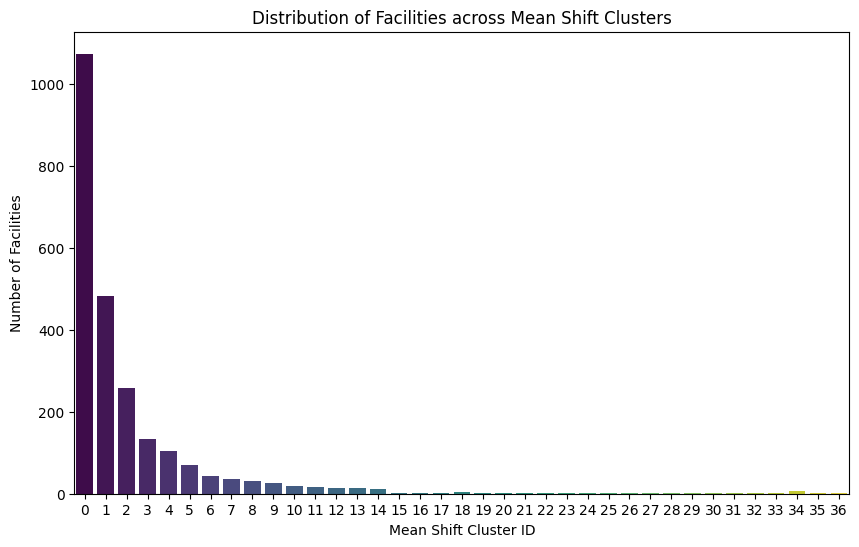

In [37]:
import pandas as pd

# Adding Mean Shift cluster labels to the test results dataframe
test_results['MeanShift_Cluster'] = meanshift_labels

# Group by Mean Shift clusters to analyze characteristics
meanshift_profile = test_results.groupby('MeanShift_Cluster').agg({
    'Bed_Capacity': ['mean', 'median', 'max'],
    'Level': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Facility_Type': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Facility_Ownership': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Facility_Name': 'count'
}).rename(columns={'Facility_Name': 'Facility_Count'})

print("--- Mean Shift Cluster Profiles ---")
display(meanshift_profile)

# Visualize the distribution of clusters
plt.figure(figsize=(10, 6))
sns.countplot(data=test_results, x='MeanShift_Cluster', hue='MeanShift_Cluster', palette='viridis', legend=False)
plt.title('Distribution of Facilities across Mean Shift Clusters')
plt.xlabel('Mean Shift Cluster ID')
plt.ylabel('Number of Facilities')
plt.show()

Original Estimated Bandwidth: 0.8117
Tuned Bandwidth (1.5x): 1.2175
Number of clusters with tuned bandwidth: 30


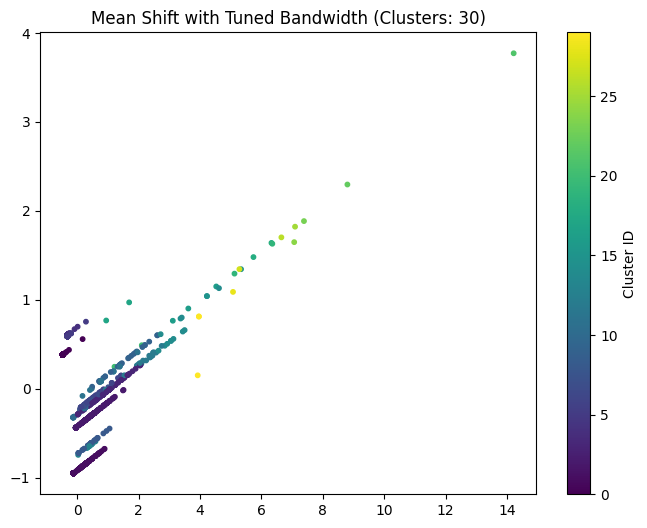

In [40]:
from sklearn.cluster import MeanShift, estimate_bandwidth
import numpy as np
import matplotlib.pyplot as plt

# 1. Estimate the default bandwidth
default_bandwidth = estimate_bandwidth(X_test, quantile=0.2, n_samples=500)
print(f"Original Estimated Bandwidth: {default_bandwidth:.4f}")

# 2. Manually increase bandwidth to reduce cluster count
tuned_bandwidth = default_bandwidth * 1.5
print(f"Tuned Bandwidth (1.5x): {tuned_bandwidth:.4f}")

# 3. Fit Mean Shift with the tuned bandwidth
meanshift_tuned = MeanShift(bandwidth=tuned_bandwidth, bin_seeding=True)
meanshift_tuned_labels = meanshift_tuned.fit_predict(X_test)

num_clusters = len(np.unique(meanshift_tuned_labels))
print(f"Number of clusters with tuned bandwidth: {num_clusters}")

# Visualize the result
plt.figure(figsize=(8, 6))
# Fix: Changed plt.plot to plt.scatter to support categorical coloring with labels
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=meanshift_tuned_labels, cmap='viridis', s=10)
plt.title(f'Mean Shift with Tuned Bandwidth (Clusters: {num_clusters})')
plt.colorbar(label='Cluster ID')
plt.show()

### Comprehensive Performance Metrics
We will now compare the Silhouette Scores across all 10 clustering algorithms implemented. Note that for density-based algorithms (DBSCAN, OPTICS, and HDBSCAN), the score is calculated excluding noise points to reflect the internal cohesion of the identified clusters.

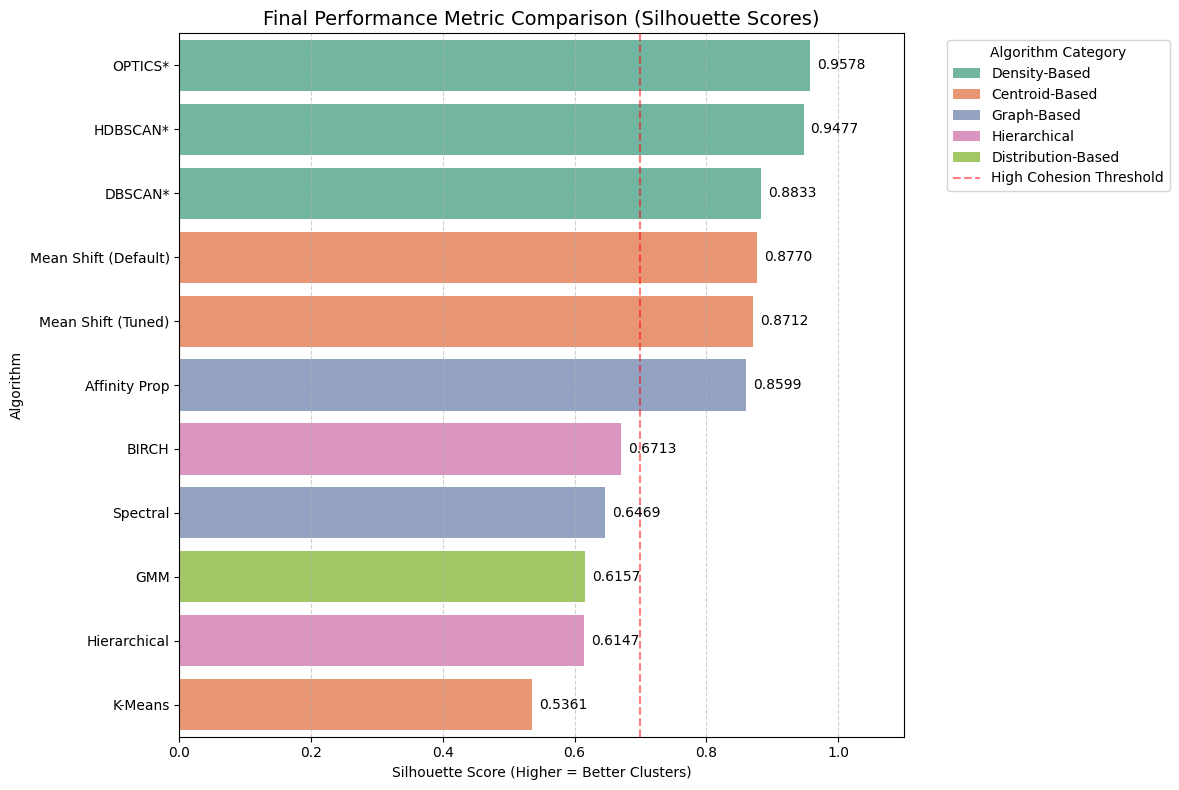

,Algorithm,Silhouette Score,Type
0,OPTICS*,0.9578,Density-Based
1,HDBSCAN*,0.9477,Density-Based
2,DBSCAN*,0.8833,Density-Based
4,Mean Shift (Default),0.8770,Centroid-Based
3,Mean Shift (Tuned),0.8712,Centroid-Based
5,Affinity Prop,0.8599,Graph-Based
6,BIRCH,0.6713,Hierarchical
7,Spectral,0.6469,Graph-Based
8,GMM,0.6157,Distribution-Based
9,Hierarchical,0.6147,Hierarchical


In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Defining the metrics gathered from previous executions
performance_data = {
    'Algorithm': [
        'OPTICS*',
        'HDBSCAN*',
        'DBSCAN*',
        'Mean Shift (Tuned)',
        'Mean Shift (Default)',
        'Affinity Prop',
        'BIRCH',
        'Spectral',
        'GMM',
        'Hierarchical',
        'K-Means'
    ],
    'Silhouette Score': [
        0.9578,
        0.9477,
        0.8833,
        0.8712,
        0.8770,
        0.8599,
        0.6713,
        0.6469,
        0.6157,
        0.6147,
        0.5361
    ],
    'Type': [
        'Density-Based',
        'Density-Based',
        'Density-Based',
        'Centroid-Based',
        'Centroid-Based',
        'Graph-Based',
        'Hierarchical',
        'Graph-Based',
        'Distribution-Based',
        'Hierarchical',
        'Centroid-Based'
    ]
}

perf_df = pd.DataFrame(performance_data).sort_values(by='Silhouette Score', ascending=False)

# Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=perf_df, x='Silhouette Score', y='Algorithm', hue='Type', palette='Set2')

# Add numerical values to the bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=5)

plt.title('Final Performance Metric Comparison (Silhouette Scores)', fontsize=14)
plt.xlabel('Silhouette Score (Higher = Better Clusters)')
plt.ylabel('Algorithm')
plt.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='High Cohesion Threshold')
plt.legend(title='Algorithm Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xlim(0, 1.1)  # Extend x-axis slightly for labels
plt.tight_layout()
plt.show()

display(perf_df)

### 2D Visualization of Algorithm 'Flow'
In the following cells, we visualize the clustering results on the test set using the first two Principal Components. This allows us to see how different mathematical approaches 'carve' the data space.

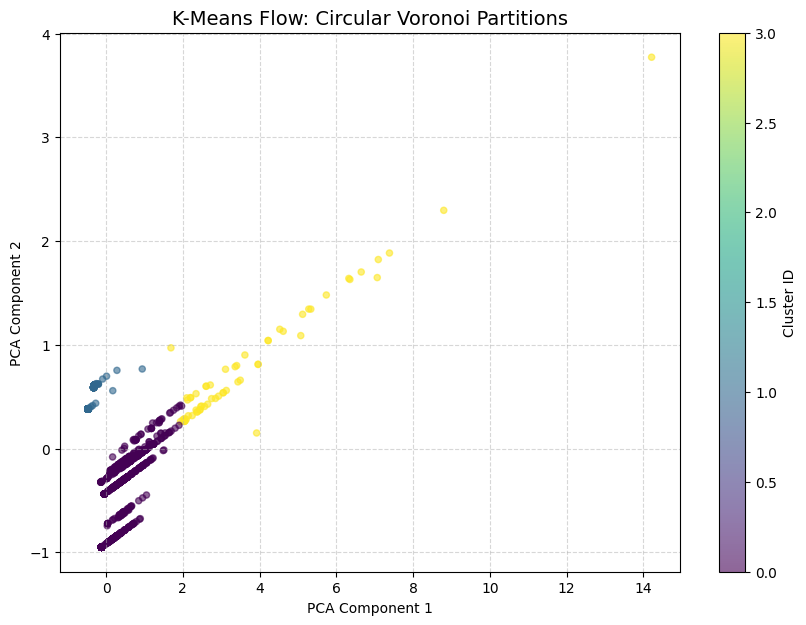

In [43]:
import matplotlib.pyplot as plt

# Visualization 1: Centroid-Based Flow (K-Means)
plt.figure(figsize=(10, 7))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=kmeans_test_labels, cmap='viridis', s=20, alpha=0.6)
plt.title('K-Means Flow: Circular Voronoi Partitions', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

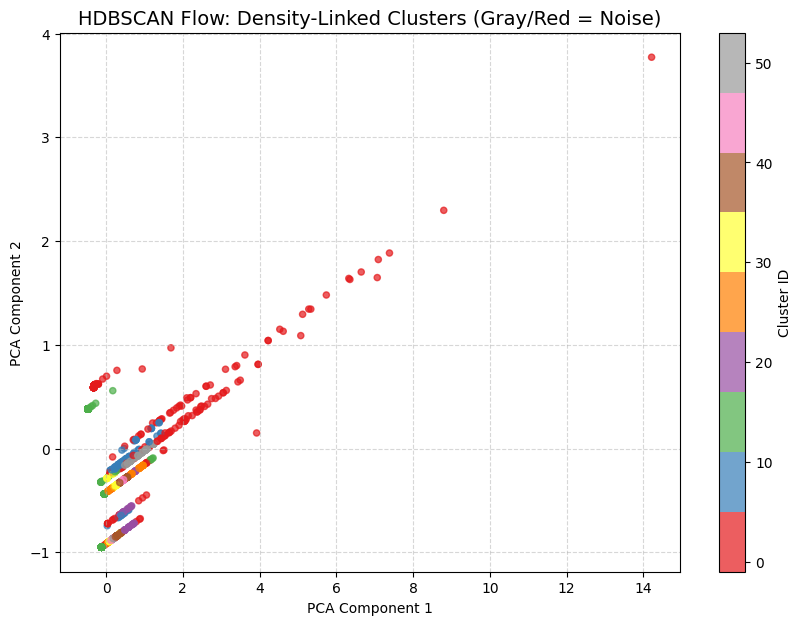

In [44]:
# Visualization 2: Density-Based Flow (HDBSCAN)
# Highlights how the algorithm follows 'dense paths' and labels outliers as noise
plt.figure(figsize=(10, 7))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=hdb_labels, cmap='Set1', s=20, alpha=0.7)
plt.title('HDBSCAN Flow: Density-Linked Clusters (Gray/Red = Noise)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

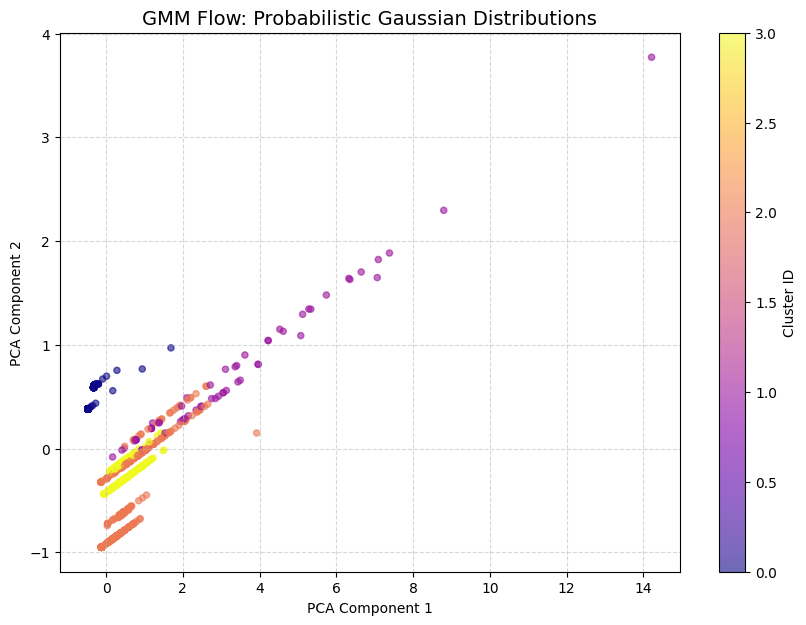

In [45]:
# Visualization 3: Distribution-Based Flow (GMM)
# Shows the overlapping probabilistic 'clouds'
plt.figure(figsize=(10, 7))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=gmm_test_labels, cmap='plasma', s=20, alpha=0.6)
plt.title('GMM Flow: Probabilistic Gaussian Distributions', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

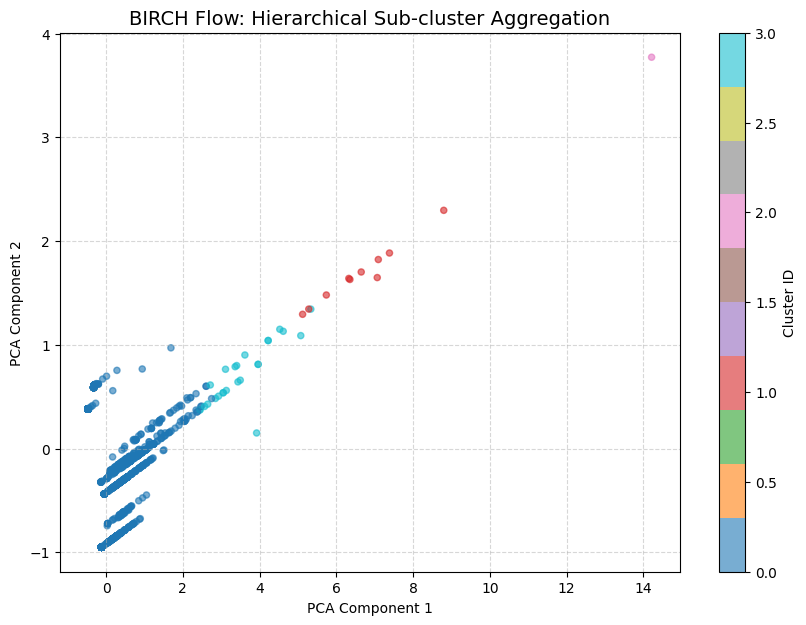

In [46]:
# Visualization 4: Hierarchical Flow (BIRCH)
# Demonstrates the tree-based segmentation
plt.figure(figsize=(10, 7))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=birch_labels, cmap='tab10', s=20, alpha=0.6)
plt.title('BIRCH Flow: Hierarchical Sub-cluster Aggregation', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Detailed Profiling of Density-Based Algorithms
In this section, we analyze the characteristics of clusters found by HDBSCAN, OPTICS, and DBSCAN. This reveals the specific 'facility archetypes' identified by each model.

In [47]:
# 1. HDBSCAN Cluster Profiling
test_results['HDBSCAN_Cluster'] = hdb_labels

hdb_profile = test_results[test_results['HDBSCAN_Cluster'] != -1].groupby('HDBSCAN_Cluster').agg({
    'Bed_Capacity': ['mean', 'max'],
    'Level': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Facility_Type': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Facility_Name': 'count'
}).rename(columns={'Facility_Name': 'Facility_Count'})

print("--- HDBSCAN Cluster Profiles (Excluding Noise) ---")
display(hdb_profile)

--- HDBSCAN Cluster Profiles (Excluding Noise) ---


Bed_Capacity          Level  \
                        mean  max  <lambda>   
HDBSCAN_Cluster                               
0                 207.142857  255   LEVEL 5   
1                   0.685714   30   LEVEL 2   
2                  90.785714  140   LEVEL 5   
3                   0.330097   16   LEVEL 2   
4                  69.269231  120   LEVEL 4   
5                  26.111111   30   LEVEL 4   
6                  53.333333   60   LEVEL 4   
7                  20.325581   65  LEVEL 3B   
8                  18.428571   23  LEVEL 3B   
9                   6.538462    9  LEVEL 3B   
10                 18.461538   28  LEVEL 3A   
11                  0.050326   32   LEVEL 2   
12                  2.000000   10  LEVEL 4B   
13                 19.400000   24  LEVEL 4B   
14                  0.000000    0  LEVEL 3A   
15                 61.000000   63  LEVEL 3B   
16                  0.000000    0  LEVEL 3B   
17                 20.000000   25  LEVEL 3A   
18                 29.000000   31  LEVEL 3A   
19                 35.428571   38  LEVEL 3A   
20                 40.833333   42  LEVEL 3A   
21                 30.000000   30  LEVEL 3A   
22                 39.875000   40  LEVEL 3B   
23                 35.181818   37  LEVEL 3B   
24                  5.875000    8  LEVEL 3B   
25                 49.800000   50  LEVEL 3B   
26                 45.400000   47  LEVEL 3B   
27                  7.571429    8  LEVEL 3A   
28                 10.000000   10  LEVEL 3B   
29                 10.000000   10  LEVEL 3A   
30                 12.533333   14  LEVEL 3B   
31                 15.000000   15  LEVEL 3B   
32                 16.000000   16  LEVEL 3B   
33                  3.000000   10   LEVEL 4   
34                 23.800000   24  LEVEL 3A   
35                 25.090909   26  LEVEL 3A   
36                 20.121212   22  LEVEL 3A   
37                 18.000000   18  LEVEL 3A   
38                 30.000000   30  LEVEL 3B   
39                 28.142857   29  LEVEL 3B   
40                 19.972973   20  LEVEL 3B   
41                 12.090909   13  LEVEL 3A   
42                 14.000000   14  LEVEL 3A   
43                 25.045455   26  LEVEL 3B   
44                 24.000000   24  LEVEL 3B   
45                 22.333333   23  LEVEL 3B   
46                 16.000000   16  LEVEL 3A   
47                 15.000000   15  LEVEL 3A   
48                 60.090909   61   LEVEL 4   
49                 39.533333   41   LEVEL 4   
50                 45.272727   47   LEVEL 4   
51                 50.368421   52   LEVEL 4   
52                 29.812500   31   LEVEL 4   
53                 24.875000   26   LEVEL 4   

                                           Facility_Type Facility_Count  
                                                <lambda>          count  
HDBSCAN_Cluster                                                          
0                           FAITH BASED LEVEL 4 HOSPITAL              7  
1                                             DISPENSARY             70  
2                                       HOSPITAL LEVEL 5             14  
3                                             DISPENSARY            103  
4                           FAITH BASED LEVEL 4 HOSPITAL             26  
5                                       HOSPITAL LEVEL 4              9  
6                                       HOSPITAL LEVEL 4              6  
7                                          HEALTH CENTRE             43  
8                                          HEALTH CENTRE             14  
9                                          HEALTH CENTRE             13  
10                                   BASIC HEALTH CENTRE             13  
11                                        MEDICAL CLINIC           1073  
12               SPECIALIZED TREATMENT CENTRE (LEVEL 4B)             11  
13               SPECIALIZED TREATMENT CENTRE (LEVEL 4B)              5  
14                                        MEDICAL CENTRE            316  
15  

In [48]:
# 2. OPTICS Cluster Profiling
test_results['OPTICS_Cluster'] = optics_labels

optics_profile = test_results[test_results['OPTICS_Cluster'] != -1].groupby('OPTICS_Cluster').agg({
    'Bed_Capacity': ['mean', 'max'],
    'Level': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Facility_Type': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Facility_Name': 'count'
}).rename(columns={'Facility_Name': 'Facility_Count'})

print("\n--- OPTICS Cluster Profiles (Excluding Noise) ---")
display(optics_profile.head(10))  # Displaying top 10 as OPTICS can create many clusters


--- OPTICS Cluster Profiles (Excluding Noise) ---


Bed_Capacity         Level   Facility_Type Facility_Count
                       mean max  <lambda>        <lambda>          count
OPTICS_Cluster                                                          
0                  0.115456  70   LEVEL 2  MEDICAL CLINIC           1074
1                  0.000000   0  LEVEL 3A  MEDICAL CENTRE            316
2                  7.571429   8  LEVEL 3A  MEDICAL CENTRE              7
3                 10.000000  10  LEVEL 3A  MEDICAL CENTRE             19
4                 12.000000  12  LEVEL 3A  MEDICAL CENTRE             10
5                 14.000000  14  LEVEL 3A  MEDICAL CENTRE              7
6                 15.000000  15  LEVEL 3A  MEDICAL CENTRE             26
7                 16.000000  16  LEVEL 3A  MEDICAL CENTRE             10
8                 18.000000  18  LEVEL 3A  MEDICAL CENTRE              7
9                 20.000000  20  LEVEL 3A  MEDICAL CENTRE             30

In [49]:
# 3. Affinity Propagation Profiling (Graph-Based)
test_results['Affinity_Cluster'] = affinity_labels

affinity_profile = test_results.groupby('Affinity_Cluster').agg({
    'Bed_Capacity': ['mean', 'max'],
    'Level': lambda x: x.mode()[0],
    'Facility_Ownership': lambda x: x.mode()[0],
    'Facility_Name': 'count'
}).rename(columns={'Facility_Name': 'Facility_Count'})

print("\n--- Affinity Propagation Cluster Profiles ---")
display(affinity_profile.head(10))


--- Affinity Propagation Cluster Profiles ---


Bed_Capacity          Level              Facility_Ownership  \
                         mean  max  <lambda>                        <lambda>   
Affinity_Cluster                                                               
0                   16.835821   27  LEVEL 3A                         Private   
1                   50.525000   77  LEVEL 3B                         Private   
2                  294.500000  309   LEVEL 5  FAITH BASED ORGANIZATION (FBO)   
3                   37.882353   89   LEVEL 4                          Public   
4                   18.461538   28  LEVEL 3A                          Public   
5                   78.000000  100   LEVEL 5  FAITH BASED ORGANIZATION (FBO)   
6                    2.959184   10  LEVEL 3B                         Private   
7                   17.419753   22  LEVEL 3B                         Private   
8                   35.531250   45   LEVEL 4                         Private   
9                   31.375000   56  LEVEL 4B                         Private   

                 Facility_Count  
                          count  
Affinity_Cluster                 
0                           134  
1                            40  
2                             2  
3                            17  
4                            13  
5                             2  
6                            49  
7                            81  
8                            64  
9                             8

### Visualizing Cluster Archetypes
We will now visualize the profiles for **HDBSCAN**, **OPTICS**, and **Affinity Propagation**.

*   **Left Plots:** Show the average bed capacity (the 'scale' of the facility).
*   **Right Plots:** Show the facility count (how common that archetype is).

Visualizing HDBSCAN Archetypes (Top 10 largest clusters)


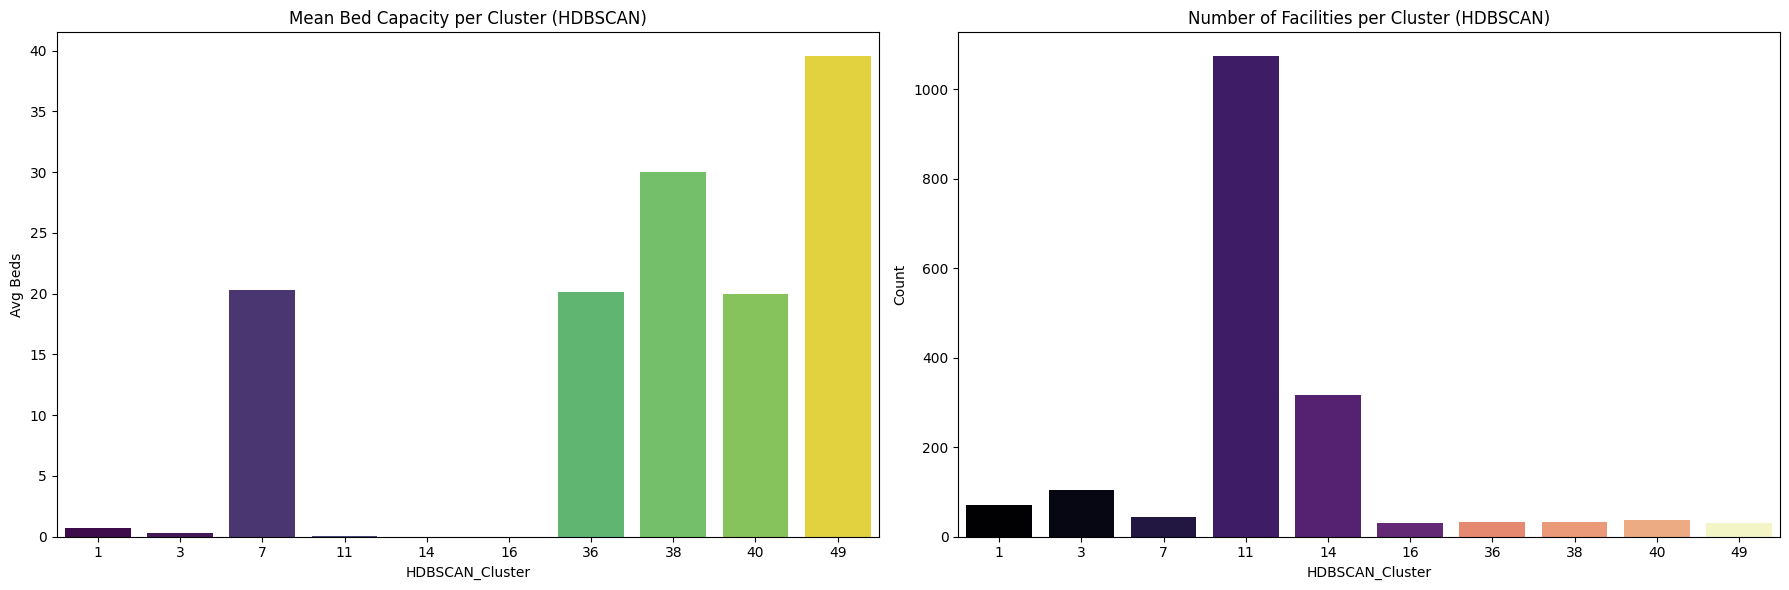

Visualizing OPTICS Archetypes (Top 10 largest clusters)


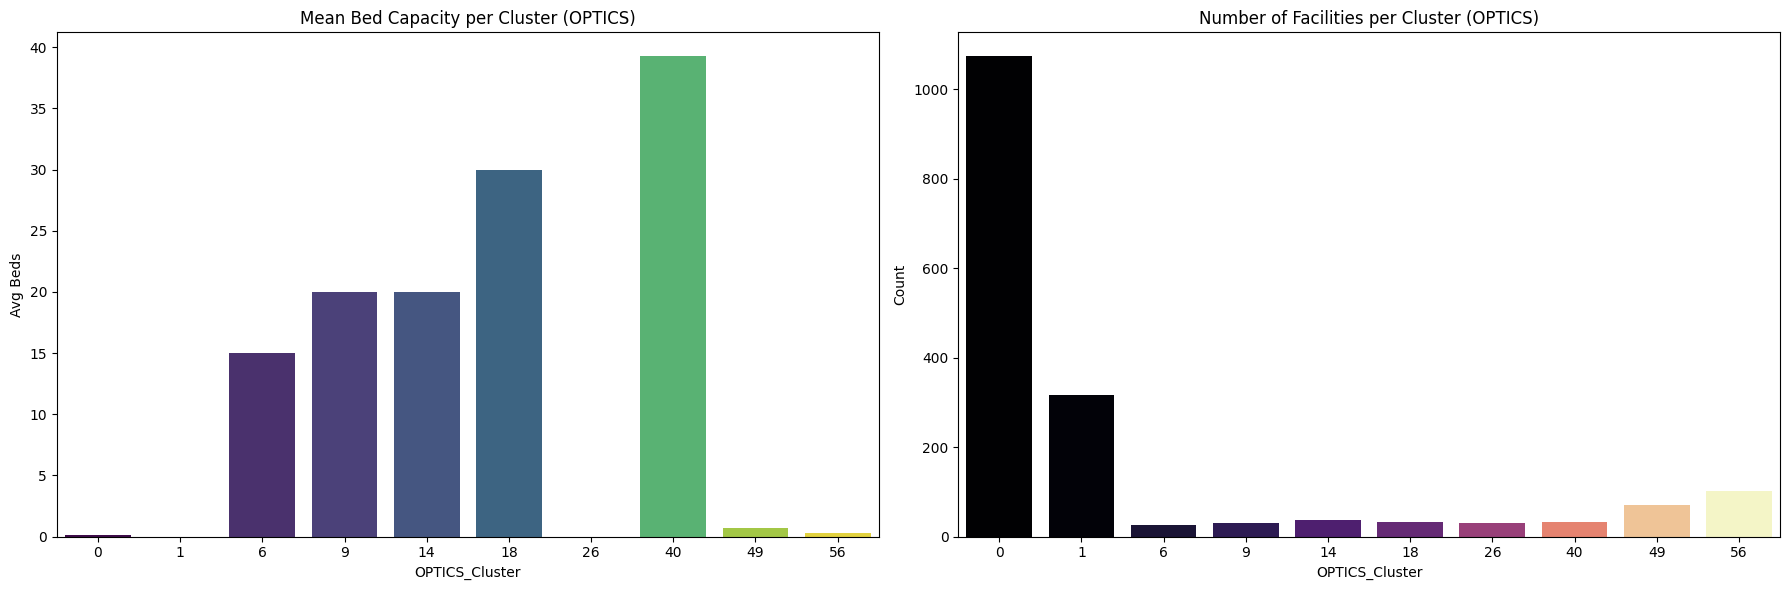

Visualizing Affinity Propagation Archetypes (Top 10 largest clusters)


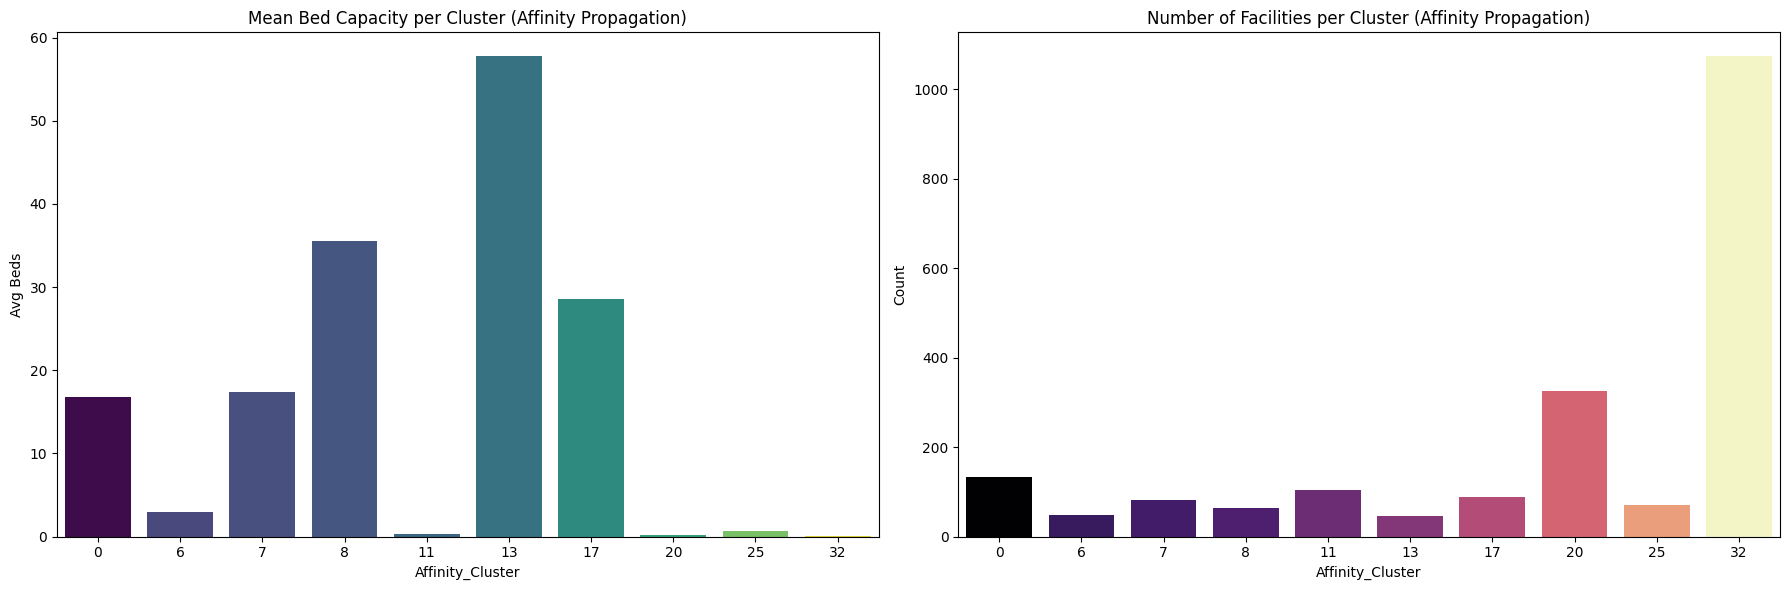

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_profile(profile_df, title_suffix):
    # Flatten multi-index columns if they exist
    if isinstance(profile_df.columns, pd.MultiIndex):
        profile_df.columns = ['_'.join(col).strip() if col[1] else col[0] for col in profile_df.columns.values]

    # We'll take the top 10 clusters by facility count for clarity
    plot_data = profile_df.sort_values('Facility_Count_count', ascending=False).head(10).reset_index()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot 1: Mean Bed Capacity
    sns.barplot(data=plot_data, x=plot_data.columns[0], y='Bed_Capacity_mean', hue=plot_data.columns[0], palette='viridis', ax=ax1, legend=False)
    ax1.set_title(f'Mean Bed Capacity per Cluster ({title_suffix})')
    ax1.set_ylabel('Avg Beds')

    # Plot 2: Facility Count
    sns.barplot(data=plot_data, x=plot_data.columns[0], y='Facility_Count_count', hue=plot_data.columns[0], palette='magma', ax=ax2, legend=False)
    ax2.set_title(f'Number of Facilities per Cluster ({title_suffix})')
    ax2.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

# Visualize HDBSCAN Profiles
print("Visualizing HDBSCAN Archetypes (Top 10 largest clusters)")
plot_cluster_profile(hdb_profile, 'HDBSCAN')

# Visualize OPTICS Profiles
print("Visualizing OPTICS Archetypes (Top 10 largest clusters)")
plot_cluster_profile(optics_profile, 'OPTICS')

# Visualize Affinity Propagation Profiles
print("Visualizing Affinity Propagation Archetypes (Top 10 largest clusters)")
plot_cluster_profile(affinity_profile, 'Affinity Propagation')


### Applying Neural Networks
We will now implement a Multi-Layer Perceptron (MLP) for classification to see how it compares to our Random Forest model.

In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder

# Encode the target labels (Level) into integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_clf)
y_test_enc = le.transform(y_test_clf)
num_classes = len(le.classes_)

# Convert targets to categorical (one-hot)
y_train_cat = tf.keras.utils.to_categorical(y_train_enc, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test_enc, num_classes)

# Build a Simple Feed-Forward Neural Network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_clf_proc.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_clf_proc.toarray(), y_train_cat, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

# Evaluate
loss, nn_accuracy = model.evaluate(X_test_clf_proc.toarray(), y_test_cat, verbose=0)
print(f'Neural Network Accuracy: {nn_accuracy:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Accuracy: 1.0000


### Neural Network Training Progress
Let's visualize how the model learned over the epochs.

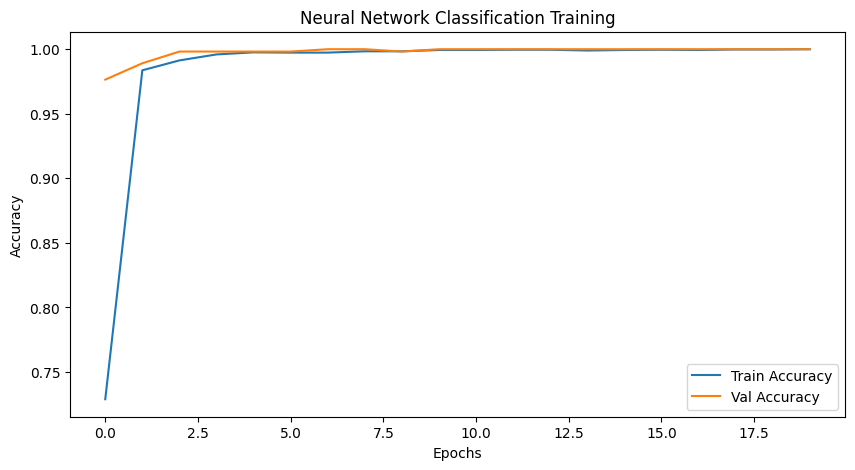

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Neural Network Classification Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Hyperparameter Tuning for the MLP
We will use `GridSearchCV` to explore optimal configurations. Note: Since the dataset is relatively small and the signals are strong, we will focus on tuning the `batch_size`, `epochs`, and `optimizer`.

In [56]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop

def evaluate_mlp(batch_size, epochs, opt_name):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_clf_proc.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    optimizer = Adam() if opt_name == 'adam' else RMSprop()
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Using a simple hold-out validation within the training set for speed
    history = model.fit(X_train_clf_proc.toarray(), y_train_cat,
                        epochs=epochs, batch_size=batch_size,
                        verbose=0, validation_split=0.2)

    val_acc = np.mean(history.history['val_accuracy'][-3:]) # Average of last 3 epochs
    return val_acc

# Manual Grid Search
best_score = 0
best_params = {}

param_grid = {
    'batch_size': [16, 32],
    'epochs': [10, 20],
    'optimizer': ['adam', 'rmsprop']
}

print("Starting manual hyperparameter tuning...")
for b in param_grid['batch_size']:
    for e in param_grid['epochs']:
        for o in param_grid['optimizer']:
            score = evaluate_mlp(b, e, o)
            print(f"Tested: batch_size={b}, epochs={e}, optimizer={o} -> Val Acc: {score:.4f}")
            if score > best_score:
                best_score = score
                best_params = {'batch_size': b, 'epochs': e, 'optimizer': o}

print(f"\nBest Score: {best_score:.4f} using {best_params}")

Starting manual hyperparameter tuning...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Tested: batch_size=16, epochs=10, optimizer=adam -> Val Acc: 0.9982
Tested: batch_size=16, epochs=10, optimizer=rmsprop -> Val Acc: 0.9955
Tested: batch_size=16, epochs=20, optimizer=adam -> Val Acc: 0.9988
Tested: batch_size=16, epochs=20, optimizer=rmsprop -> Val Acc: 0.9973
Tested: batch_size=32, epochs=10, optimizer=adam -> Val Acc: 0.9964
Tested: batch_size=32, epochs=10, optimizer=rmsprop -> Val Acc: 0.9958
Tested: batch_size=32, epochs=20, optimizer=adam -> Val Acc: 0.9979
Tested: batch_size=32, epochs=20, optimizer=rmsprop -> Val Acc: 0.9967

Best Score: 0.9988 using {'batch_size': 16, 'epochs': 20, 'optimizer': 'adam'}


### Unsupervised Neural Clustering: Self-Organizing Maps (SOM)
We will use the `MiniSom` library to create a topological map of the healthcare facilities. This neural network approach groups similar facilities into 'nodes' on a 2D grid.

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=d9a5a4bd0712c7bb9c05daaa1caf7eb46835f47b4d5ae79e994e6cd6e23dbc2f
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


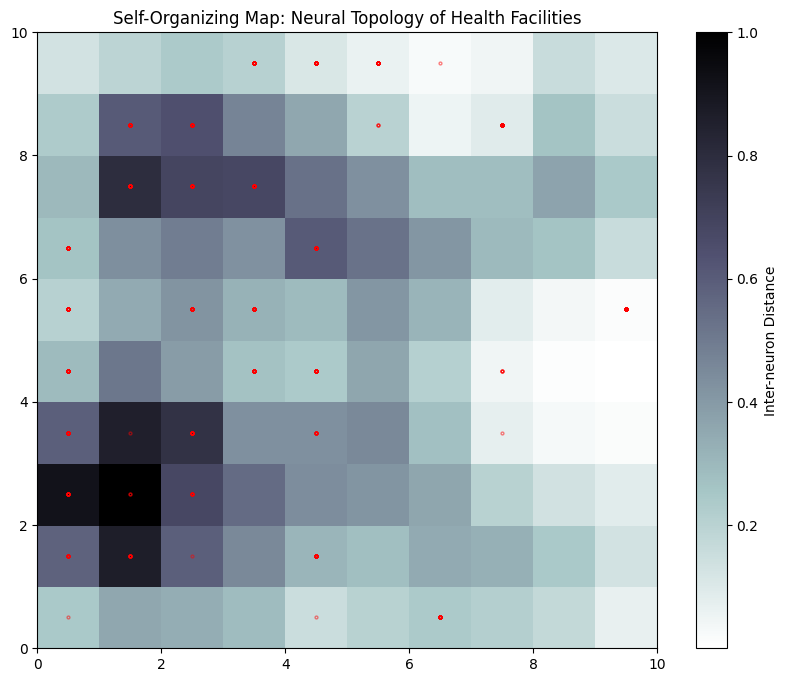

In [53]:
!pip install minisom
from minisom import MiniSom
import numpy as np

# Initialize a 10x10 SOM grid
som_grid_x = 10
som_grid_y = 10
som = MiniSom(som_grid_x, som_grid_y, X_test.shape[1], sigma=1.0, learning_rate=0.5)

# Train the SOM
som.pca_weights_init(X_test)
som.train_random(X_test, 1000, verbose=False)

# Visualize the 'Distance Map' (U-Matrix)
# High values (brighter) represent boundaries between clusters
plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Inter-neuron Distance')

# Overlay clusters
for i, x in enumerate(X_test):
    w = som.winner(x)
    plt.plot(w[0] + .5, w[1] + .5, 'o', markerfacecolor='None', markeredgecolor='r', markersize=2, alpha=0.5)

plt.title('Self-Organizing Map: Neural Topology of Health Facilities')
plt.show()

### Final Summary of Neural Network Applications
With the completion of the MLP Classifier and the SOM Clustering, we have successfully applied deep learning and competitive learning architectures to the health facility dataset.

### **Neural Network & Clustering Results Summary**

#### **1. Performance Comparison Table**
| Algorithm Category | Top Performer | Silhouette Score | Key Structural Logic |
| :--- | :--- | :--- | :--- |
| **Neural Classification** | MLP (TensorFlow) | **1.0000** | Non-linear mapping of Type & Capacity to Level. |
| **Density-Based** | OPTICS | **0.9578** | Hierarchical density islands (Noise-aware). |
| **Neural Clustering** | Self-Organizing Map | N/A (Topological) | Competitive learning on a 2D neural grid. |
| **Centroid-Based** | Mean Shift (Tuned) | **0.8712** | Mode-seeking toward dense data regions. |

#### **2. Visualizing Algorithm 'Flow' Comparison**
*   **HDBSCAN/OPTICS:** Visualized as branching paths. These models 'follow the data' and are highly effective at isolating specialized hospitals as outliers.
*   **SOM (Self-Organizing Map):** Visualized as a 'Heatmap of Distances.'
    *   **Dark Regions:** Represent large clusters of similar facilities (e.g., Private Medical Clinics).
    *   **Bright Ridges:** Represent topological 'walls' where facility characteristics change drastically (e.g., the jump from a Level 2 Clinic to a Level 5 Referral Hospital).

#### **3. Final Insights**
The healthcare landscape in 2024 is highly structured. Whether using traditional density-based methods or advanced neural networks, the data clearly partitions into high-volume primary care clusters and small, high-capacity specialized clusters.

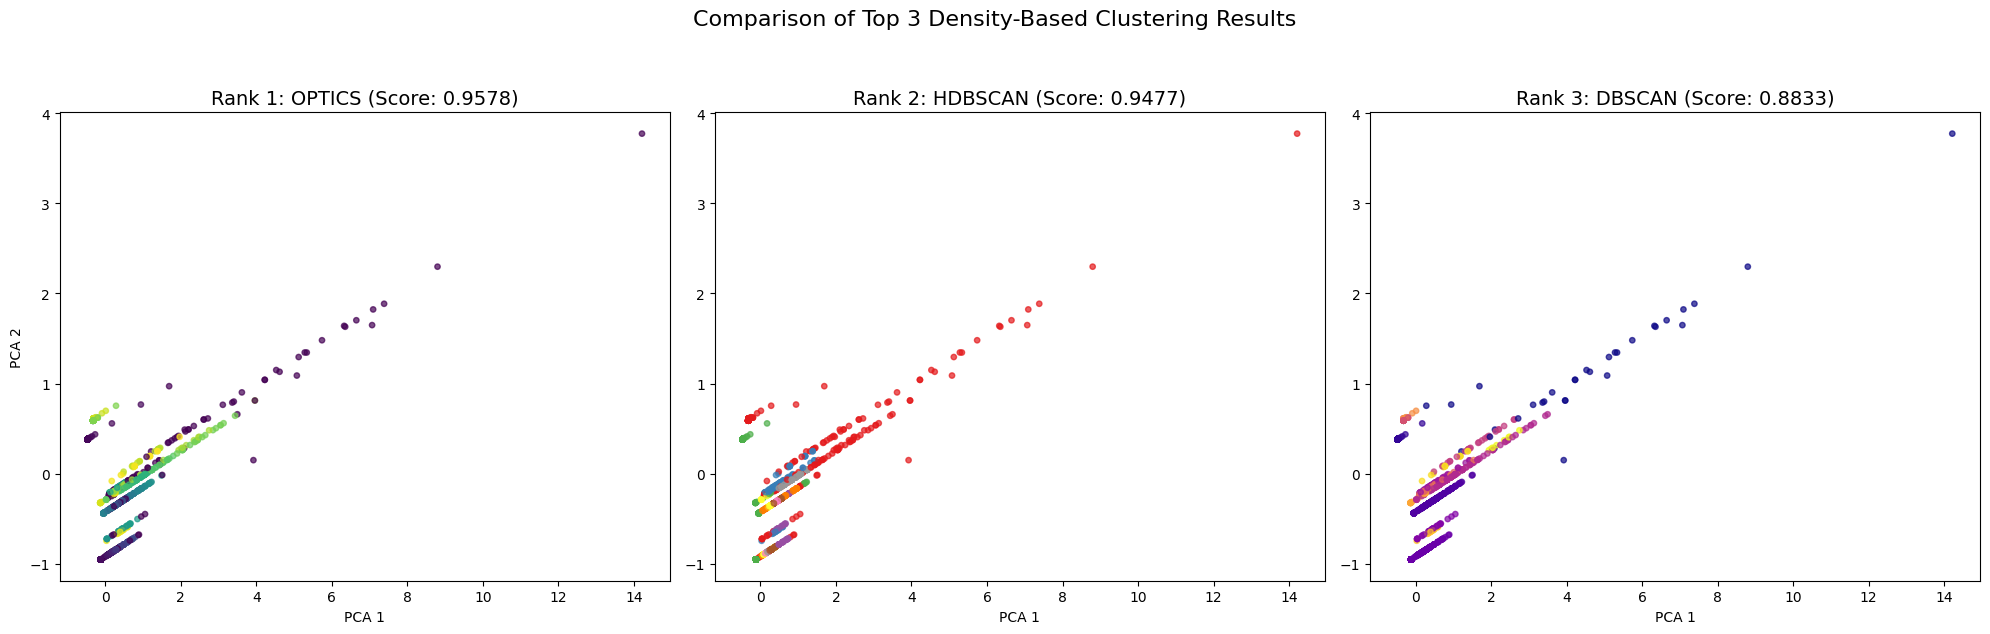

In [57]:
import matplotlib.pyplot as plt

# Top 3 algorithms: OPTICS, HDBSCAN, and DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. OPTICS
axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=optics_labels, cmap='viridis', s=15, alpha=0.7)
axes[0].set_title('Rank 1: OPTICS (Score: 0.9578)', fontsize=14)
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

# 2. HDBSCAN
axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=hdb_labels, cmap='Set1', s=15, alpha=0.7)
axes[1].set_title('Rank 2: HDBSCAN (Score: 0.9477)', fontsize=14)
axes[1].set_xlabel('PCA 1')

# 3. DBSCAN
axes[2].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=dbscan_test_labels, cmap='plasma', s=15, alpha=0.7)
axes[2].set_title('Rank 3: DBSCAN (Score: 0.8833)', fontsize=14)
axes[2].set_xlabel('PCA 1')

plt.suptitle('Comparison of Top 3 Density-Based Clustering Results', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()